<a href="https://colab.research.google.com/github/costpetrides/FAIRMODE-WG5/blob/main/Phase2/New_IDW_Mult_PM25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import netCDF4 as nc
from sklearn.neighbors import BallTree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from tqdm import tqdm
import itertools

# ======================================================
# LOAD DATA
# ======================================================
df = pd.read_csv("basePM25_gridcell_average.csv")
df["bias_ratio"] = df["SURF_ug_PM25_rh50"] / df["nearest_SURF_ug_PM25_rh50"]

dataset = nc.Dataset("EMEP_yearly_2015.nc", "r")
lon = dataset.variables["lon"][:]
lat = dataset.variables["lat"][:]
model = dataset.variables["SURF_ug_PM25_rh50"][0, :, :]
dataset.close()

# ======================================================
# PREPARE DATA
# ======================================================
cell_points = np.column_stack([
    np.radians(df["nearest_grid_lat"].values),
    np.radians(df["nearest_grid_lon"].values)
])

bias_values = df["bias_ratio"].values
obs_values = df["SURF_ug_PM25_rh50"].values

# Precompute grid indices
cell_indices = [
    (
        np.argmin(np.abs(lat - df["nearest_grid_lat"].iloc[i])),
        np.argmin(np.abs(lon - df["nearest_grid_lon"].iloc[i]))
    )
    for i in range(len(df))
]

# ======================================================
# PARAMETERS
# ======================================================
p_values = np.arange(0.2, 3.1, 0.1)
k_values = np.arange(2, 41)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

# ======================================================
# GRID SEARCH
# ======================================================
with tqdm(total=len(p_values) * len(k_values), desc="Grid Search") as pbar:

    for p, k in itertools.product(p_values, k_values):

        all_val_obs = []
        all_val_pred = []

        for train_idx, val_idx in kf.split(cell_points):

            train_points = cell_points[train_idx]
            train_bias = bias_values[train_idx]

            val_points = cell_points[val_idx]
            val_obs = obs_values[val_idx]

            tree = BallTree(train_points, metric="haversine")
            dists, idxs = tree.query(val_points, k=k)

            dists = np.maximum(dists, 1e-12)

            weights = 1 / (dists ** p)
            weights /= weights.sum(axis=1, keepdims=True)

            interpolated_bias = np.sum(weights * train_bias[idxs], axis=1)

            val_pred = []
            for i_local, idx_global in enumerate(val_idx):
                i_grid, j_grid = cell_indices[idx_global]
                val_pred.append(model[i_grid, j_grid] * interpolated_bias[i_local])

            val_pred = np.array(val_pred)

            all_val_obs.extend(val_obs)
            all_val_pred.extend(val_pred)

        # ======================================================
        # METRICS
        # ======================================================
        all_val_obs = np.array(all_val_obs)
        all_val_pred = np.array(all_val_pred)

        rmse = np.sqrt(mean_squared_error(all_val_obs, all_val_pred))
        mae = mean_absolute_error(all_val_obs, all_val_pred)
        mbe = np.mean(all_val_pred - all_val_obs)
        r2 = r2_score(all_val_obs, all_val_pred)

        denom = all_val_pred + all_val_obs
        mask = denom != 0
        fb = np.mean(2 * (all_val_pred[mask] - all_val_obs[mask]) / denom[mask]) if np.any(mask) else np.nan

        results.append((p, k, rmse, mae, mbe, r2, fb))

        pbar.update(1)

# ======================================================
# RESULTS DATAFRAME
# ======================================================
results_df = pd.DataFrame(
    results,
    columns=["p", "k", "RMSE", "MAE", "MBE", "R2", "FB"]
)

results_df["abs_MBE"] = np.abs(results_df["MBE"])
results_df["abs_FB"] = np.abs(results_df["FB"])

results_df.to_csv("fast_gridsearch_metrics.csv", index=False)

# ======================================================
# PARETO FRONT
# ======================================================
pareto_rows = []

for i, row_i in results_df.iterrows():

    dominated = False

    for j, row_j in results_df.iterrows():

        if j == i:
            continue

        if (
            (row_j["RMSE"] <= row_i["RMSE"]) and
            (row_j["MAE"] <= row_i["MAE"]) and
            (row_j["abs_MBE"] <= row_i["abs_MBE"]) and
            (row_j["abs_FB"] <= row_i["abs_FB"]) and
            (
                (row_j["RMSE"] < row_i["RMSE"]) or
                (row_j["MAE"] < row_i["MAE"]) or
                (row_j["abs_MBE"] < row_i["abs_MBE"]) or
                (row_j["abs_FB"] < row_i["abs_FB"])
            )
        ):
            dominated = True
            break

    if not dominated:
        pareto_rows.append(row_i)

pareto_df = pd.DataFrame(pareto_rows)

print("\nPareto-optimal solutions:")
print(pareto_df[["p", "k", "RMSE", "MAE", "MBE", "FB"]])

# ======================================================
# BEST COMPROMISE (DISTANCE TO IDEAL)
# ======================================================
def safe_norm(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-12)

norm_rmse = safe_norm(pareto_df["RMSE"])
norm_mae  = safe_norm(pareto_df["MAE"])
norm_mbe  = safe_norm(pareto_df["abs_MBE"])
norm_fb   = safe_norm(pareto_df["abs_FB"])

pareto_df["dist_to_ideal"] = np.sqrt(
    norm_rmse**2 +
    norm_mae**2 +
    norm_mbe**2 +
    norm_fb**2
)

best_idx = pareto_df["dist_to_ideal"].idxmin()
best_params = (pareto_df.loc[best_idx, "p"], pareto_df.loc[best_idx, "k"])

print(f"\nBEST COMPROMISE (Pareto): p={best_params[0]}, k={best_params[1]}")

# ======================================================
# FINAL MODEL
# ======================================================
print("\nApplying final model...")

lon_mesh, lat_mesh = np.meshgrid(lon, lat)
grid_points = np.column_stack([
    np.radians(lat_mesh.ravel()),
    np.radians(lon_mesh.ravel())
])

tree = BallTree(cell_points, metric="haversine")
dists, idxs = tree.query(grid_points, k=int(best_params[1]))

dists = np.maximum(dists, 1e-12)

weights = 1 / (dists ** best_params[0])
weights /= weights.sum(axis=1, keepdims=True)

final_bias = np.sum(weights * bias_values[idxs], axis=1)
final_bias = final_bias.reshape(model.shape)

out_nc = nc.Dataset("BaseCase_PM25_rh50_Y_IDW_MUL.nc", "w", format="NETCDF4")

out_nc.createDimension("lat", len(lat))
out_nc.createDimension("lon", len(lon))

lat_var = out_nc.createVariable("lat", "f4", ("lat",))
lon_var = out_nc.createVariable("lon", "f4", ("lon",))
bias_var = out_nc.createVariable("Interpolated_Bias", "f4", ("lat", "lon"))

lat_var[:] = lat
lon_var[:] = lon
bias_var[:, :] = final_bias

out_nc.close()

print("Saved: BaseCase_PM25_rh50_Y_IDW_MUL.nc")

Grid Search: 100%|██████████| 1131/1131 [00:24<00:00, 45.88it/s]



Pareto-optimal solutions:
        p     k      RMSE       MAE       MBE        FB
235   0.8   3.0  3.904138  2.441559  0.013077  0.000546
274   0.9   3.0  3.908122  2.443354  0.008661  0.000166
313   1.0   3.0  3.913416  2.446260  0.004879 -0.000189
352   1.1   3.0  3.919784  2.451800  0.001666 -0.000521
391   1.2   3.0  3.927029  2.457717 -0.001042 -0.000831
...   ...   ...       ...       ...       ...       ...
1016  2.8   4.0  4.015169  2.531363  0.000107 -0.002079
1051  2.8  39.0  3.861916  2.442353  0.014769 -0.000426
1052  2.8  40.0  3.862567  2.442746  0.013844 -0.000478
1090  2.9  39.0  3.876660  2.451654  0.013361 -0.000679
1091  2.9  40.0  3.877241  2.451954  0.012497 -0.000728

[120 rows x 6 columns]

BEST COMPROMISE (Pareto): p=2.200000000000001, k=26.0

Applying final model...
Saved: BaseCase_PM25_rh50_Y_IDW_MUL.nc



=== DATA RANGES ===
RMSE: min=3.7011, max=4.4157
MAE: min=2.2960, max=2.7341
R2: min=0.5657, max=0.6949
MBE: min=-0.0419, max=0.3658


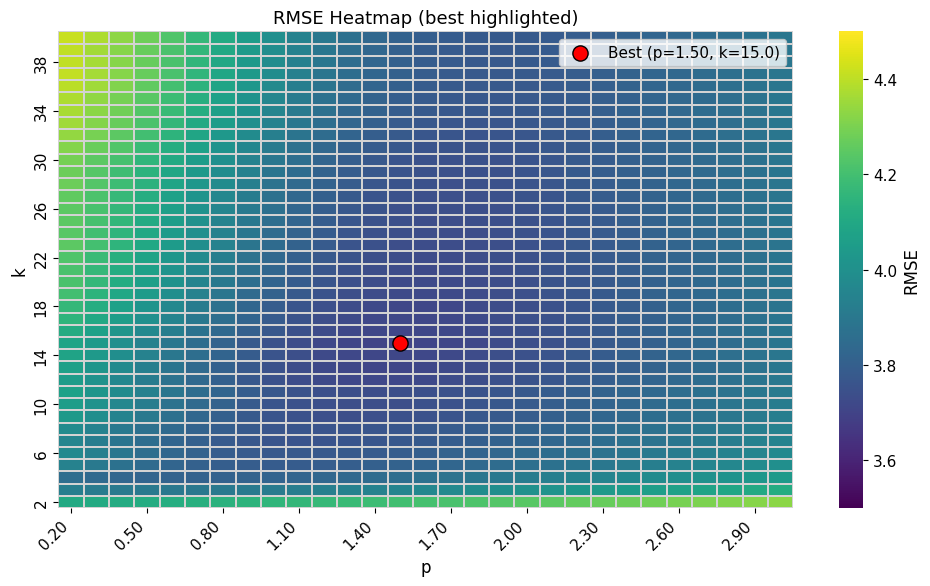

RMSE best → p=1.50, k=15.0, value=3.7011


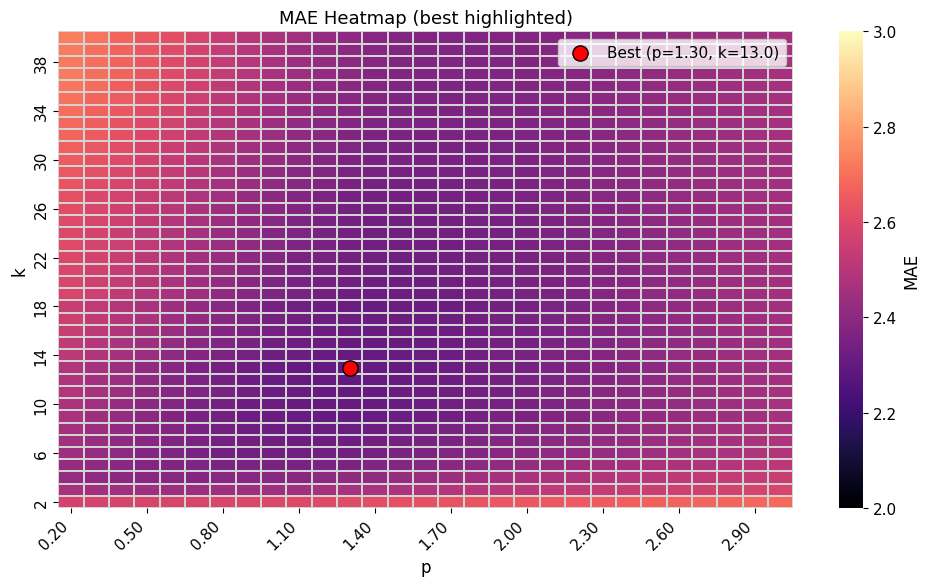

MAE best → p=1.30, k=13.0, value=2.2960


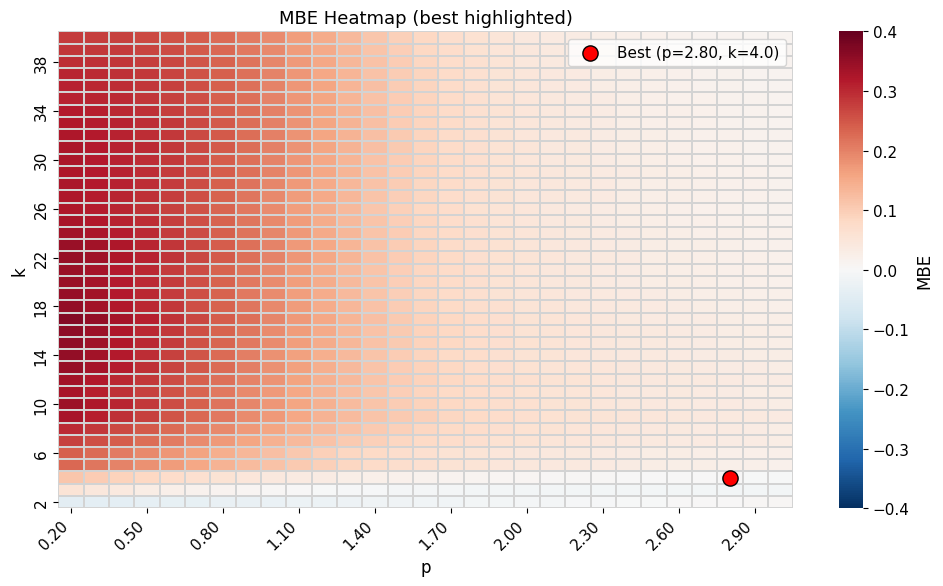

MBE best → p=2.80, k=4.0, value=0.0001


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ======================================================
# GLOBAL STYLE (clean)
# ======================================================
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12
})

# ======================================================
# 1. LOAD RESULTS
# ======================================================
df = pd.read_csv("fast_gridsearch_metrics.csv")

df["p"] = df["p"].astype(float).round(2)   # FIX float noise
df["k"] = df["k"].astype(int)

# ======================================================
# 2. PRINT REAL DATA RANGES
# ======================================================
print("\n=== DATA RANGES ===")
for col in ["RMSE", "MAE", "R2", "MBE"]:
    print(f"{col}: min={df[col].min():.4f}, max={df[col].max():.4f}")

# ======================================================
# 3. GET BEST (p, k) PER METRIC
# ======================================================
def get_best_params(metric):

    if metric in ["RMSE", "MAE"]:
        row = df.loc[df[metric].idxmin()]

    elif metric == "R2":
        row = df.loc[df[metric].idxmax()]

    elif metric == "MBE":
        row = df.iloc[(df["MBE"].abs()).idxmin()]

    else:
        raise ValueError("Unknown metric")

    return row["p"], row["k"], row[metric]

# ======================================================
# 4. HEATMAP FUNCTION (FIXED AXES)
# ======================================================
def plot_heatmap(metric, cmap="viridis", center=None, vmin=None, vmax=None):

    pivot = df.pivot(index="k", columns="p", values=metric)
    pivot = pivot.sort_index().sort_index(axis=1)

    # Fix floating precision in axis
    pivot.columns = pivot.columns.round(2)

    best_p, best_k, best_val = get_best_params(metric)

    plt.figure(figsize=(10, 6))

    ax = sns.heatmap(
        pivot,
        cmap=cmap,
        center=center,
        vmin=vmin,
        vmax=vmax,
        linewidths=0.1,
        linecolor="lightgray",
        cbar_kws={"label": metric}
    )

    plt.title(f"{metric} Heatmap (best highlighted)")
    plt.xlabel("p")
    plt.ylabel("k")

    # ==================================================
    # CLEAN AXES (KEY FIX)
    # ==================================================
    step_x = 3   # reduce p ticks
    step_y = 4   # reduce k ticks

    ax.set_xticks(np.arange(0, len(pivot.columns), step_x) + 0.5)
    ax.set_xticklabels(
        [f"{p:.2f}" for p in pivot.columns[::step_x]],
        rotation=45,
        ha="right"
    )

    ax.set_yticks(np.arange(0, len(pivot.index), step_y) + 0.5)
    ax.set_yticklabels(pivot.index[::step_y])

    # ==================================================
    # BEST POINT
    # ==================================================
    x_idx = list(pivot.columns).index(round(best_p, 2))
    y_idx = list(pivot.index).index(best_k)

    plt.scatter(
        x_idx + 0.5,
        y_idx + 0.5,
        color="red",
        s=120,
        edgecolors="black",
        linewidth=1,
        label=f"Best (p={best_p:.2f}, k={best_k})"
    )

    # Optional: invert y-axis (more intuitive)
    plt.gca().invert_yaxis()

    plt.legend()
    plt.tight_layout()

    # Save figure
    plt.savefig(f"{metric}_heatmap.png", dpi=300, bbox_inches="tight")

    plt.show()

    print(f"{metric} best → p={best_p:.2f}, k={best_k}, value={best_val:.4f}")

# ======================================================
# 5. MANUAL LIMITS
# ======================================================
limits = {
    "RMSE": (3.5, 4.5),
    "MAE":  (2, 3),
    "R2":   (0, 1),
    "MBE":  (-0.4, 0.4)
}

# ======================================================
# 6. PLOTS
# ======================================================
plot_heatmap("RMSE", cmap="viridis",
             vmin=limits["RMSE"][0], vmax=limits["RMSE"][1])

plot_heatmap("MAE", cmap="magma",
             vmin=limits["MAE"][0], vmax=limits["MAE"][1])

plot_heatmap("MBE", cmap="RdBu_r", center=0,
             vmin=limits["MBE"][0], vmax=limits["MBE"][1])

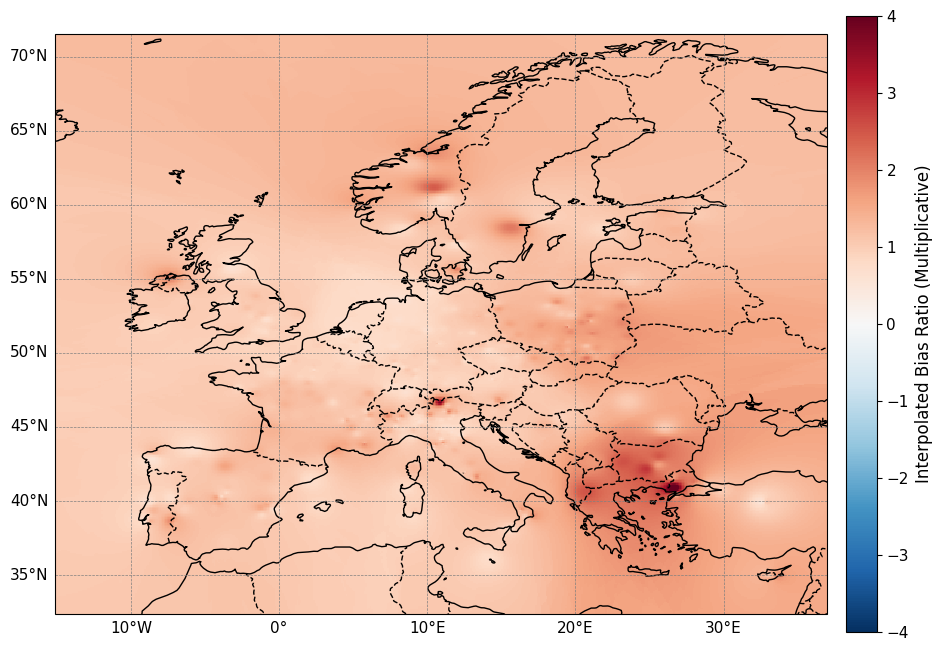

In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# === Load the Interpolated Bias Ratio NetCDF File ===
bias_netcdf_path = "BaseCase_PM25_rh50_Y_IDW_MUL.nc"
ds_bias = xr.open_dataset(bias_netcdf_path)

# Extract interpolated bias ratio
interpolated_bias_ratio = ds_bias["Interpolated_Bias"].squeeze().values

# Extract coordinates
lon = ds_bias["lon"].values
lat = ds_bias["lat"].values

# === Define Plot Limits (Adjust if needed) ===
cbar_min = -4 # Set minimum scale for bias ratio
cbar_max = 4  # Set maximum scale for bias ratio

# Create a plot with Cartopy
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the interpolated bias ratio
im = ax.pcolormesh(lon, lat, interpolated_bias_ratio, transform=ccrs.PlateCarree(), cmap="RdBu_r", vmin=cbar_min, vmax=cbar_max, shading='auto')

# Add colorbar
cbar = plt.colorbar(im, orientation="vertical", pad=0.02)
cbar.set_label("Interpolated Bias Ratio (Multiplicative)")

# Add country borders and coastlines
ax.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="black", linewidth=1)
ax.coastlines(resolution="50m", linewidth=1)

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_bias.close()

In [4]:
import netCDF4 as nc
import numpy as np

# === Define File Paths ===
original_nc_path = "EMEP_yearly_2015.nc"
bias_ratio_nc_path = "BaseCase_PM25_rh50_Y_IDW_MUL.nc"
corrected_nc_path = "BaseCase_Corrected_PM25_rh50_Y_MUL.nc"

# === Load the Original Modeled PM₂.₅ NetCDF ===
with nc.Dataset(original_nc_path, "r") as original_nc, nc.Dataset(bias_ratio_nc_path, "r") as bias_nc:

    # Load model coordinates and data
    lon = original_nc.variables["lon"][:]
    lat = original_nc.variables["lat"][:]
    time = original_nc.variables["time"][:]
    pm25_original = original_nc.variables["SURF_ug_PM25_rh50"][:]

    # Load the interpolated bias ratio
    interpolated_bias_ratio = bias_nc.variables["Interpolated_Bias"][:]

    # === Apply Multiplicative Bias Correction ===
    # Ensure bias ratio does not contain values too close to zero
    min_bias_threshold = 0.1  # Prevent extreme scaling
    interpolated_bias_ratio = np.maximum(interpolated_bias_ratio, min_bias_threshold)

    # Correct PM₂.₅
    pm25_corrected = pm25_original * interpolated_bias_ratio  # Multiplicative correction

    # === Save the Corrected PM₂.₅ to a New NetCDF File ===
    with nc.Dataset(corrected_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        pm25_var = new_nc.createVariable("SURF_ug_PM25_rh50_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the original PM₂.₅ variable
        pm25_var.setncatts(original_nc.variables["SURF_ug_PM25_rh50"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        pm25_var[:] = pm25_corrected  # Store corrected PM₂.₅

print(" Multiplicative Bias Correction Completed Successfully!")
print(" Corrected PM₂.₅ NetCDF file saved as:", corrected_nc_path)


 Multiplicative Bias Correction Completed Successfully!
 Corrected PM₂.₅ NetCDF file saved as: BaseCase_Corrected_PM25_rh50_Y_MUL.nc


In [5]:

import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "BaseCase_Corrected_PM25_rh50_Y_MUL.nc"  # Your original file
output_file = "BaseCase_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2015.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_PM25_rh50_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh50 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")



 Correction completed! Renamed and fixed NetCDF saved as: BaseCase_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_PM25_rh50']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh50 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc', 'NCO': 'netCDF Operators versi

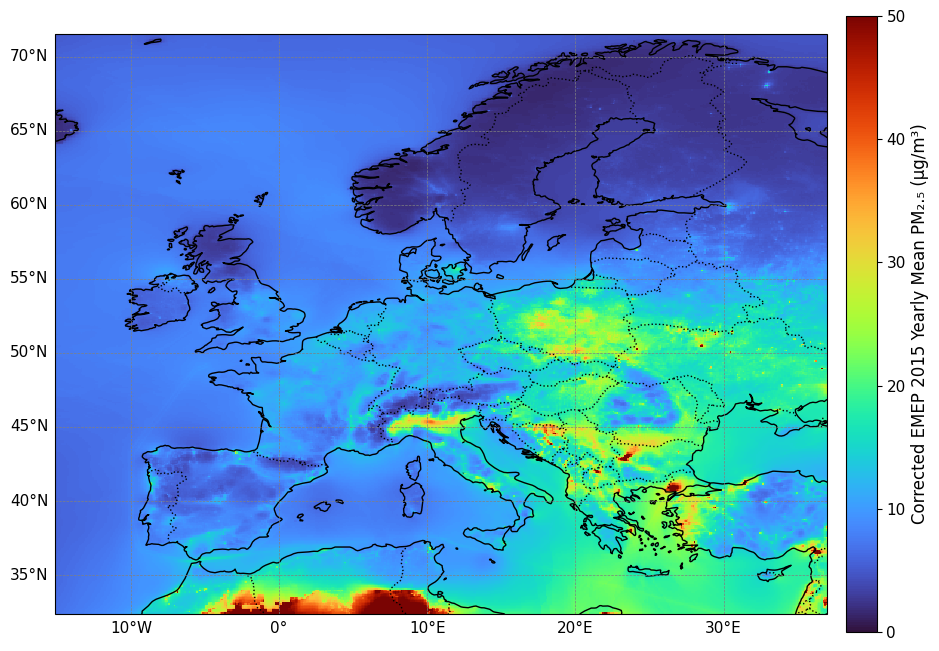

In [6]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected O₃ NetCDF File ===
corrected_netcdf_path = "BaseCase_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected O₃ values
corrected_o3 = ds_corrected["SURF_ug_PM25_rh50"].squeeze().values.T


# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Logarithmic Scale for Color Normalization ===
norm = mcolors.Normalize(0, 50)  # Log scale between 1 and max value (adjust if needed)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the O₃ concentration using pcolormesh with logarithmic scaling
mesh = ax.pcolormesh(Lon, Lat, corrected_o3, cmap='turbo', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar with logarithmic scaling
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2015 Yearly Mean PM₂.₅ (µg/m³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()

# EMEP 2O22

In [7]:
import netCDF4 as nc
import numpy as np

# === Define File Paths ===
scenario_perturbed_nc_path = "EMEP_yearly_2022.nc"  # Perturbed Scenario NetCDF
bias_residual_nc_path = "BaseCase_PM25_rh50_Y_IDW_MUL.nc"  # Interpolated Bias Ratios NetCDF
corrected_scenario_nc_path = "Scenario_Corrected_PM25_MUL.nc"  # Output Corrected Scenario NetCDF

# === Load NetCDF Files ===
with nc.Dataset(scenario_perturbed_nc_path, "r") as scen_nc, \
     nc.Dataset(bias_residual_nc_path, "r") as bias_nc:

    # Load model grid & PM₂.₅ data
    lon = scen_nc.variables["lon"][:]
    lat = scen_nc.variables["lat"][:]
    time = scen_nc.variables["time"][:]

    pm25_scenario_perturbed = scen_nc.variables["SURF_ug_PM25_rh50"][:]  # Perturbed Scenario PM₂.₅
    interpolated_bias_ratios = bias_nc.variables["Interpolated_Bias"][:]  # Interpolated OBS/MOD ratios

    # === Apply Multiplicative Correction ===
    min_ratio_threshold = 0.1  # Optional safeguard
    interpolated_bias_ratios = np.maximum(interpolated_bias_ratios, min_ratio_threshold)

    pm25_scenario_corrected = pm25_scenario_perturbed * interpolated_bias_ratios

    # === Save the Corrected Scenario to a New NetCDF File ===
    with nc.Dataset(corrected_scenario_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        pm25_var = new_nc.createVariable("SURF_ug_PM25_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy metadata attributes from the original scenario file
        pm25_var.setncatts(scen_nc.variables["SURF_ug_PM25_rh50"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        pm25_var[:] = pm25_scenario_corrected

print("Multiplicative IDW Bias Correction Applied Successfully!")
print("Corrected PM₂.₅ Scenario NetCDF saved as:", corrected_scenario_nc_path)


Multiplicative IDW Bias Correction Applied Successfully!
Corrected PM₂.₅ Scenario NetCDF saved as: Scenario_Corrected_PM25_MUL.nc


In [8]:

import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "Scenario_Corrected_PM25_MUL.nc"  # Your original file
output_file = "Scen_2022_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2022.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_PM25_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")

 Correction completed! Renamed and fixed NetCDF saved as: Scen_2022_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_PM25_rh50']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc', 'NCO': 'netCDF Operators versi

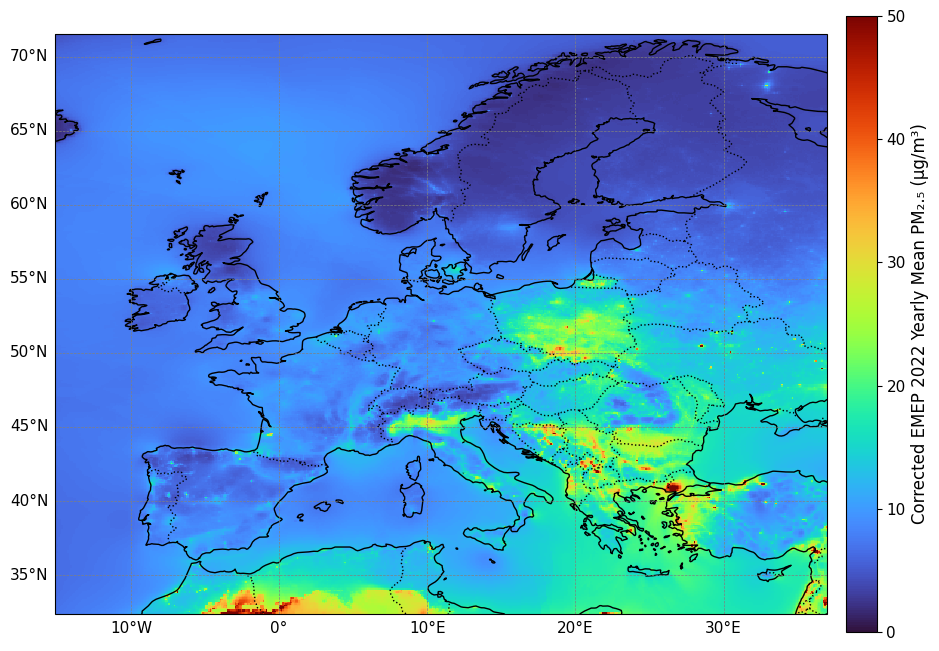

In [9]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected O₃ NetCDF File ===
corrected_netcdf_path = "Scen_2022_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected O₃ values
corrected_o3 = ds_corrected["SURF_ug_PM25_rh50"].squeeze().values.T


# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Logarithmic Scale for Color Normalization ===
norm = mcolors.Normalize(0, 50)  # Log scale between 1 and max value (adjust if needed)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the O₃ concentration using pcolormesh with logarithmic scaling
mesh = ax.pcolormesh(Lon, Lat, corrected_o3, cmap='turbo', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar with logarithmic scaling
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2022 Yearly Mean PM₂.₅ (µg/m³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()

# EMEP 2O23

In [10]:
import netCDF4 as nc
import numpy as np

# === Define File Paths ===
scenario_perturbed_nc_path = "EMEP_yearly_2023.nc"  # Perturbed Scenario NetCDF
bias_residual_nc_path = "BaseCase_PM25_rh50_Y_IDW_MUL.nc"  # Interpolated Bias Ratios NetCDF
corrected_scenario_nc_path = "Scenario_Corrected3_PM25_MUL.nc"  # Output Corrected Scenario NetCDF

# === Load NetCDF Files ===
with nc.Dataset(scenario_perturbed_nc_path, "r") as scen_nc, \
     nc.Dataset(bias_residual_nc_path, "r") as bias_nc:

    # Load model grid & PM₂.₅ data
    lon = scen_nc.variables["lon"][:]
    lat = scen_nc.variables["lat"][:]
    time = scen_nc.variables["time"][:]

    pm25_scenario_perturbed = scen_nc.variables["SURF_ug_PM25_rh50"][:]  # Perturbed Scenario PM₂.₅
    interpolated_bias_ratios = bias_nc.variables["Interpolated_Bias"][:]  # Interpolated OBS/MOD ratios

    # === Apply Multiplicative Correction ===
    min_ratio_threshold = 0.1  # Optional safeguard
    interpolated_bias_ratios = np.maximum(interpolated_bias_ratios, min_ratio_threshold)

    pm25_scenario_corrected = pm25_scenario_perturbed * interpolated_bias_ratios

    # === Save the Corrected Scenario to a New NetCDF File ===
    with nc.Dataset(corrected_scenario_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        pm25_var = new_nc.createVariable("SURF_ug_PM25_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy metadata attributes from the original scenario file
        pm25_var.setncatts(scen_nc.variables["SURF_ug_PM25_rh50"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        pm25_var[:] = pm25_scenario_corrected

print("Multiplicative IDW Bias Correction Applied Successfully!")
print("Corrected PM₂.₅ Scenario NetCDF saved as:", corrected_scenario_nc_path)


Multiplicative IDW Bias Correction Applied Successfully!
Corrected PM₂.₅ Scenario NetCDF saved as: Scenario_Corrected3_PM25_MUL.nc


In [11]:

import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "Scenario_Corrected3_PM25_MUL.nc"  # Your original file
output_file = "Scen_2023_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2023.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_PM25_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")

 Correction completed! Renamed and fixed NetCDF saved as: Scen_2023_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_PM25_rh50']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc', 'NCO': 'netCDF Operators versi

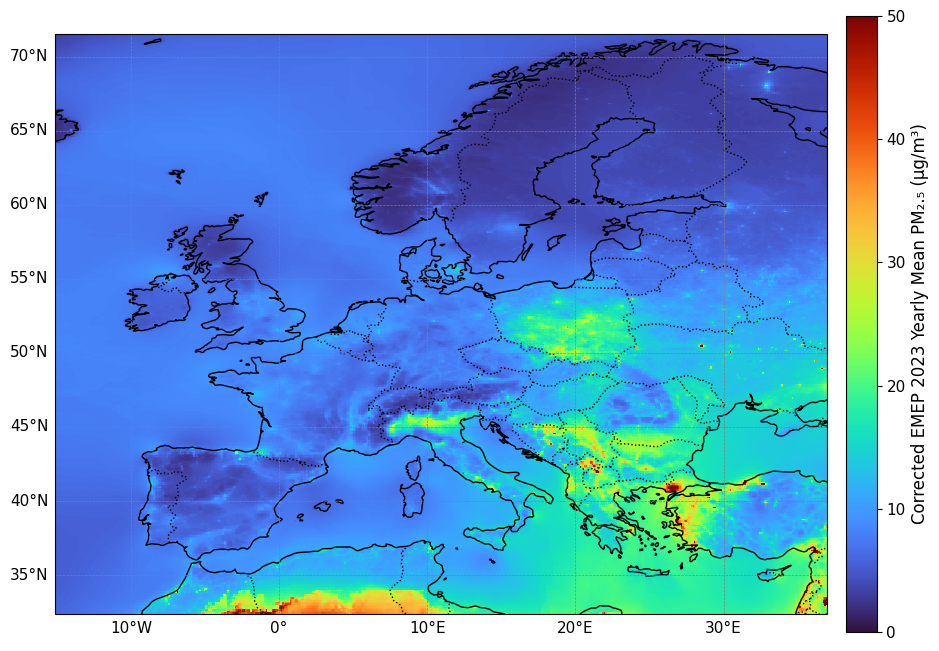

In [12]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected O₃ NetCDF File ===
corrected_netcdf_path = "Scen_2023_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected O₃ values
corrected_o3 = ds_corrected["SURF_ug_PM25_rh50"].squeeze().values.T


# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Logarithmic Scale for Color Normalization ===
norm = mcolors.Normalize(0, 50)  # Log scale between 1 and max value (adjust if needed)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the O₃ concentration using pcolormesh with logarithmic scaling
mesh = ax.pcolormesh(Lon, Lat, corrected_o3, cmap='turbo', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar with logarithmic scaling
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2023 Yearly Mean PM₂.₅ (µg/m³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()

# EMEP 2024

In [13]:
import netCDF4 as nc
import numpy as np

# === Define File Paths ===
scenario_perturbed_nc_path = "EMEP_yearly_2024.nc"  # Perturbed Scenario NetCDF
bias_residual_nc_path = "BaseCase_PM25_rh50_Y_IDW_MUL.nc"  # Interpolated Bias Ratios NetCDF
corrected_scenario_nc_path = "Scenario_Corrected4_PM25_MUL.nc"  # Output Corrected Scenario NetCDF

# === Load NetCDF Files ===
with nc.Dataset(scenario_perturbed_nc_path, "r") as scen_nc, \
     nc.Dataset(bias_residual_nc_path, "r") as bias_nc:

    # Load model grid & PM₂.₅ data
    lon = scen_nc.variables["lon"][:]
    lat = scen_nc.variables["lat"][:]
    time = scen_nc.variables["time"][:]

    pm25_scenario_perturbed = scen_nc.variables["SURF_ug_PM25_rh50"][:]  # Perturbed Scenario PM₂.₅
    interpolated_bias_ratios = bias_nc.variables["Interpolated_Bias"][:]  # Interpolated OBS/MOD ratios

    # === Apply Multiplicative Correction ===
    min_ratio_threshold = 0.1  # Optional safeguard
    interpolated_bias_ratios = np.maximum(interpolated_bias_ratios, min_ratio_threshold)

    pm25_scenario_corrected = pm25_scenario_perturbed * interpolated_bias_ratios

    # === Save the Corrected Scenario to a New NetCDF File ===
    with nc.Dataset(corrected_scenario_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        pm25_var = new_nc.createVariable("SURF_ug_PM25_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy metadata attributes from the original scenario file
        pm25_var.setncatts(scen_nc.variables["SURF_ug_PM25_rh50"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        pm25_var[:] = pm25_scenario_corrected

print("Multiplicative IDW Bias Correction Applied Successfully!")
print("Corrected PM₂.₅ Scenario NetCDF saved as:", corrected_scenario_nc_path)


Multiplicative IDW Bias Correction Applied Successfully!
Corrected PM₂.₅ Scenario NetCDF saved as: Scenario_Corrected4_PM25_MUL.nc


In [14]:

import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "Scenario_Corrected4_PM25_MUL.nc"  # Your original file
output_file = "Scen_2024_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2024.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_PM25_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")

 Correction completed! Renamed and fixed NetCDF saved as: Scen_2024_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_PM25_rh50']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc', 'NCO': 'netCDF Operators versi

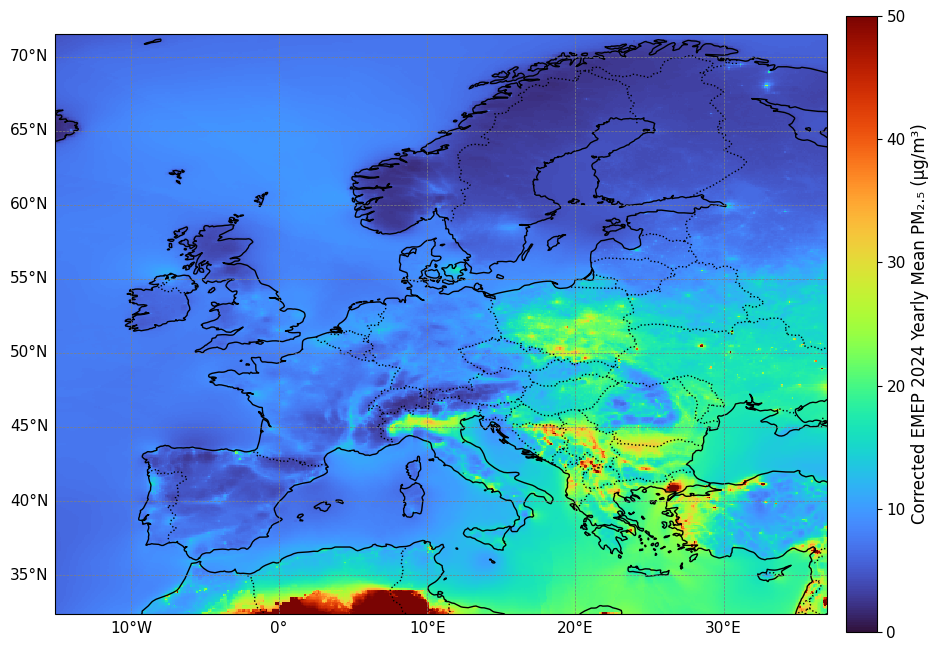

In [15]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected O₃ NetCDF File ===
corrected_netcdf_path = "Scen_2024_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected O₃ values
corrected_o3 = ds_corrected["SURF_ug_PM25_rh50"].squeeze().values.T


# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Logarithmic Scale for Color Normalization ===
norm = mcolors.Normalize(0, 50)  # Log scale between 1 and max value (adjust if needed)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the O₃ concentration using pcolormesh with logarithmic scaling
mesh = ax.pcolormesh(Lon, Lat, corrected_o3, cmap='turbo', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar with logarithmic scaling
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2024 Yearly Mean PM₂.₅ (µg/m³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()

In [16]:
import numpy as np
import os

input_dir = "/content/PM25"
output_dir = "/content/Results_PM25"

variables_to_fix = [
    "SURF_ug_NO2",
    "SURF_ug_O3",              # corrected name
    "SURF_ug_PM25_rh50"
]

correct_dims = ("time", "lat", "lon")

os.makedirs(output_dir, exist_ok=True)

for file in os.listdir(input_dir):
    if file.endswith(".nc"):

        input_path = os.path.join(input_dir, file)
        output_path = os.path.join(output_dir, file)

        print(f"\nProcessing: {file}")

        with nc.Dataset(input_path, "r") as src:
            lon = src.variables["lon"][:]
            lat = src.variables["lat"][:]
            time = src.variables["time"][:]

            global_attrs = {attr: src.getncattr(attr) for attr in src.ncattrs()}

            with nc.Dataset(output_path, "w", format="NETCDF4") as dst:

                # === FIXED DIMENSIONS ===
                dst.createDimension("lon", len(lon))
                dst.createDimension("lat", len(lat))
                dst.createDimension("time", len(time))   # NOT unlimited

                # === COORDINATES (correct dtype) ===
                lon_var = dst.createVariable("lon", "f8", ("lon",))
                lat_var = dst.createVariable("lat", "f8", ("lat",))
                time_var = dst.createVariable("time", "f8", ("time",))

                lon_var[:] = lon
                lat_var[:] = lat
                time_var[:] = time

                # Copy coordinate attributes
                for coord in ["lon", "lat", "time"]:
                    for attr in src.variables[coord].ncattrs():
                        getattr(dst.variables[coord], "setncattr")(
                            attr, src.variables[coord].getncattr(attr)
                        )

                # === Global attributes ===
                for attr, value in global_attrs.items():
                    dst.setncattr(attr, value)

                # === Variables ===
                for var_name in variables_to_fix:

                    if var_name not in src.variables:
                        print(f"  ⚠ {var_name} not found.")
                        continue

                    var = src.variables[var_name]
                    dims = var.dimensions
                    data = var[:]
                    var_attrs = {a: var.getncattr(a) for a in var.ncattrs()}

                    # === Reshape if needed ===
                    if dims != correct_dims:

                        print(f"   Reshaping {var_name}: {dims} → {correct_dims}")

                        if dims == ("lon", "lat", "time"):
                            data = np.transpose(data, (2, 1, 0))
                        elif dims == ("lat", "lon", "time"):
                            data = np.transpose(data, (2, 0, 1))
                        else:
                            print(f"   ⚠ Unknown dimension order {dims}")
                            continue

                    # === Write variable ===
                    fill_value = var_attrs.pop("_FillValue", -9999.0)

                    var_out = dst.createVariable(
                        var_name,
                        "f4",
                        correct_dims,
                        fill_value=fill_value
                    )

                    for attr, value in var_attrs.items():
                        var_out.setncattr(attr, value)

                    var_out[:] = data

        print(f"  ✔ Saved to {output_path}")

print("\n✔ All files processed correctly.")


Processing: Scen_2024_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc
  ⚠ SURF_ug_NO2 not found.
  ⚠ SURF_ug_O3 not found.
   Reshaping SURF_ug_PM25_rh50: ('lon', 'lat', 'time') → ('time', 'lat', 'lon')
  ✔ Saved to /content/Results_PM25/Scen_2024_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

Processing: BaseCase_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc
  ⚠ SURF_ug_NO2 not found.
  ⚠ SURF_ug_O3 not found.
   Reshaping SURF_ug_PM25_rh50: ('lon', 'lat', 'time') → ('time', 'lat', 'lon')
  ✔ Saved to /content/Results_PM25/BaseCase_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

Processing: Scen_2023_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc
  ⚠ SURF_ug_NO2 not found.
  ⚠ SURF_ug_O3 not found.
   Reshaping SURF_ug_PM25_rh50: ('lon', 'lat', 'time') → ('time', 'lat', 'lon')
  ✔ Saved to /content/Results_PM25/Scen_2023_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

Processing: Scen_2022_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc
  ⚠ SURF_ug_NO2 not found.
  ⚠ SURF_ug_O3 not found.
   Reshaping SURF_ug_PM25_rh5

Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 5.258649539145988
MAE: 3.4413187849404934
Bias: -1.0608119106907434
R: 0.6669691567549353
R² (corr): 0.44484785606238947
R² (true): 0.3843458981471186

ADI
RMSE: 0.9006508572891895
MAE: 0.47533705494087836
Bias: -0.1436890713496075
R: 0.9911614235736984
R² (corr): 0.9824009675806404
R² (true): 0.9819406857975197

===== COUNTRY METRICS =====
   Country   RMSE_Raw  RMSE_WDI   Bias_Raw  Bias_WDI    R2_Raw    R2_WDI    N
18      LU   2.235698  0.196690   2.190796 -0.130647  0.512935  0.897674    3
28      XK  11.856372  0.243869 -11.856372  0.243869       NaN       NaN    1
9       EE   1.434549  0.249435  -0.906214 -0.096075  0.481903  0.990569    6
4       CH   6.094740  0.276758   6.035270  0.231052  1.000000  1.000000    2
13      GB   1.725660  0.293352   0.071284  0.014027  0.266223  0.978718   31
7       DE   2.290495  0.299127   1.113937 -0.092926  0.256662  0.979085   99
17      LT   1.593971  0.327576  -1.31

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


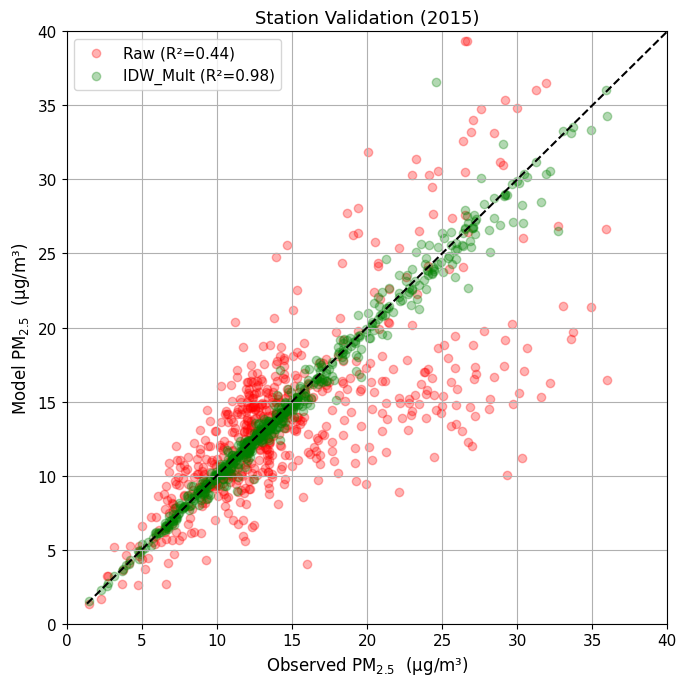

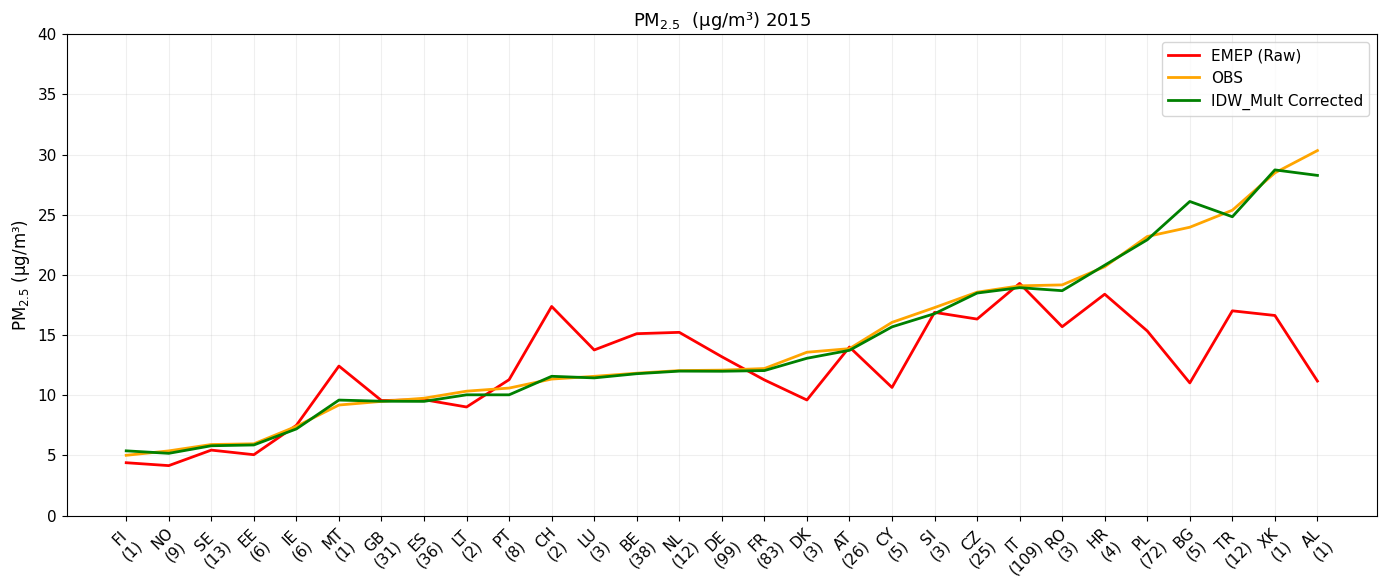

In [17]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2015.nc")
ds_wdi = xr.open_dataset("BaseCase_NKUA_PM25_CSA.Cell.Mult.IDW_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_PM25_rh50"].values
wdi = ds_wdi["SURF_ug_PM25_rh50"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_PM25_2015.csv")

if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. BILINEAR INTERPOLATION
# ======================================================
def bilinear_interp(lon_pt, lat_pt, lon, lat, field):

    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon) - 2)
    j = np.clip(j, 0, len(lat) - 2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    Q11 = field[j, i]
    Q21 = field[j, i+1]
    Q12 = field[j+1, i]
    Q22 = field[j+1, i+1]

    return (
        Q11 * (x2 - lon_pt) * (y2 - lat_pt) +
        Q21 * (lon_pt - x1) * (y2 - lat_pt) +
        Q12 * (x2 - lon_pt) * (lat_pt - y1) +
        Q22 * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(bilinear_interp(lo, la, lon, lat, raw))
    wdi_vals.append(bilinear_interp(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

# compute once
r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nADI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"IDW_Mult (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')

plt.xlabel("Observed PM$_{2.5}$  (µg/m³)")
plt.ylabel("Model PM$_{2.5}$  (µg/m³)")
plt.title("Station Validation (2015)")
plt.xlim(0,40)
plt.ylim(0,40)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="IDW_Mult Corrected")

plt.xticks(x, labels, rotation=45)
plt.ylabel("PM$_{2.5}$ (µg/m³)")
plt.title("PM$_{2.5}$  (µg/m³) 2015")
plt.ylim(0,40)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 3.0742667208470857
MAE: 2.346514510738826
Bias: 1.254383751264528
R: 0.816002925020796
R² (corr): 0.6658607736424947
R² (true): 0.495439071202608

ADI
RMSE: 4.250688522716347
MAE: 2.592161020722255
Bias: 2.2328780143835405
R: 0.8525210675060518
R² (corr): 0.7267921705416582
R² (true): 0.03539591999079328

===== COUNTRY METRICS =====
   Country  RMSE_Raw   RMSE_WDI  Bias_Raw   Bias_WDI    R2_Raw    R2_WDI   N
20      SE  0.498301   0.638216  0.308085   0.419735  0.980168  0.966107   4
3       CH  3.446547   0.930106  3.366267  -0.894308  1.000000  1.000000   2
12      IE  1.080186   0.933345  0.518302   0.158235  0.594567  0.797798   4
6       DE  2.121418   0.972375  1.404922   0.504773  0.273507  0.748025  86
1       BE  3.394064   1.458787  3.254225   0.845708  0.884049  0.816662  30
15      NL  4.048195   1.556382  3.999193   1.243308  0.038777  0.016021  11
7       EE  0.973388   1.650265  0.574261   1.423331 

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


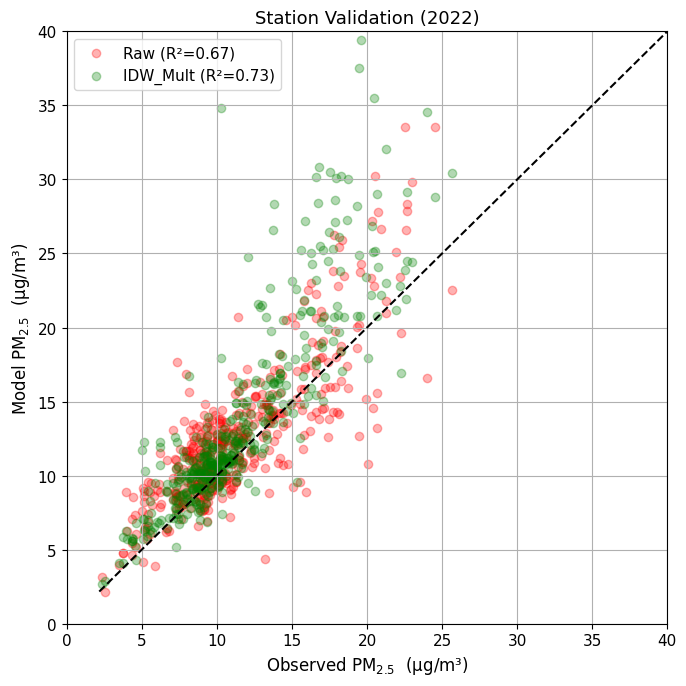

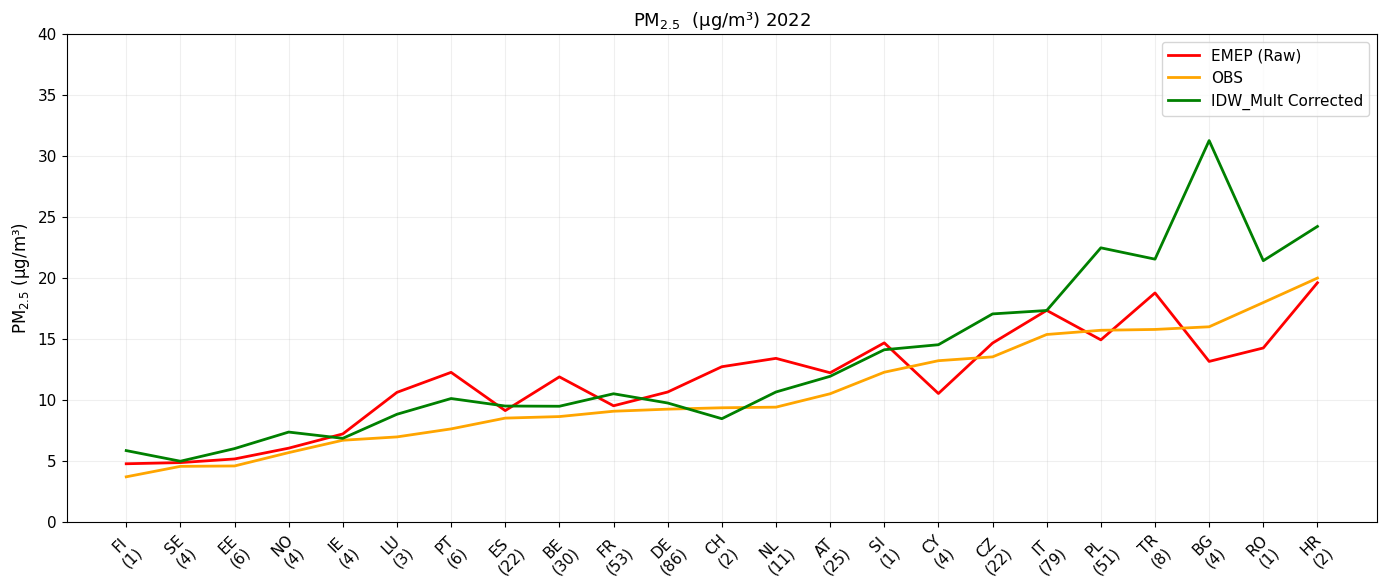

In [18]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2022.nc")
ds_wdi = xr.open_dataset("Scen_2022_NKUA_PM25_CSA.Cell.Mult.IDW_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_PM25_rh50"].values
wdi = ds_wdi["SURF_ug_PM25_rh50"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_PM25_2022.csv")

if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. BILINEAR INTERPOLATION
# ======================================================
def bilinear_interp(lon_pt, lat_pt, lon, lat, field):

    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon) - 2)
    j = np.clip(j, 0, len(lat) - 2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    Q11 = field[j, i]
    Q21 = field[j, i+1]
    Q12 = field[j+1, i]
    Q22 = field[j+1, i+1]

    return (
        Q11 * (x2 - lon_pt) * (y2 - lat_pt) +
        Q21 * (lon_pt - x1) * (y2 - lat_pt) +
        Q12 * (x2 - lon_pt) * (lat_pt - y1) +
        Q22 * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(bilinear_interp(lo, la, lon, lat, raw))
    wdi_vals.append(bilinear_interp(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

# compute once
r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nADI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"IDW_Mult (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')

plt.xlabel("Observed PM$_{2.5}$  (µg/m³)")
plt.ylabel("Model PM$_{2.5}$  (µg/m³)")
plt.title("Station Validation (2022)")
plt.xlim(0,40)
plt.ylim(0,40)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="IDW_Mult Corrected")

plt.xticks(x, labels, rotation=45)
plt.ylabel("PM$_{2.5}$ (µg/m³)")
plt.title("PM$_{2.5}$  (µg/m³) 2022")
plt.ylim(0,40)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 2.9468605827027425
MAE: 2.165125097721015
Bias: 0.7773300713905382
R: 0.7813692660277803
R² (corr): 0.6105379298927922
R² (true): 0.4746326738613982

ADI
RMSE: 3.602599508625432
MAE: 2.1755470271650825
Bias: 1.5924490435644973
R: 0.8377182427728599
R² (corr): 0.7017718542744482
R² (true): 0.21480802725876968

===== COUNTRY METRICS =====
   Country  RMSE_Raw   RMSE_WDI  Bias_Raw   Bias_WDI    R2_Raw    R2_WDI   N
12      IE  0.476634   0.334900  0.280882  -0.035931  0.710592  0.956521   4
3       CH  3.086469   0.515762  3.076622  -0.495650  1.000000  1.000000   2
6       DE  1.877030   0.855519  1.088131   0.313974  0.219194  0.701850  86
20      SE  0.505869   0.891298  0.459812   0.570122  0.995148  0.874169   4
0       AT  2.191249   1.321835  0.985831   0.768315  0.323033  0.751050  25
21      SI  1.825327   1.354907  1.825327   1.354907       NaN       NaN   1
14      LU  2.848934   1.447442  2.819398   1.299

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


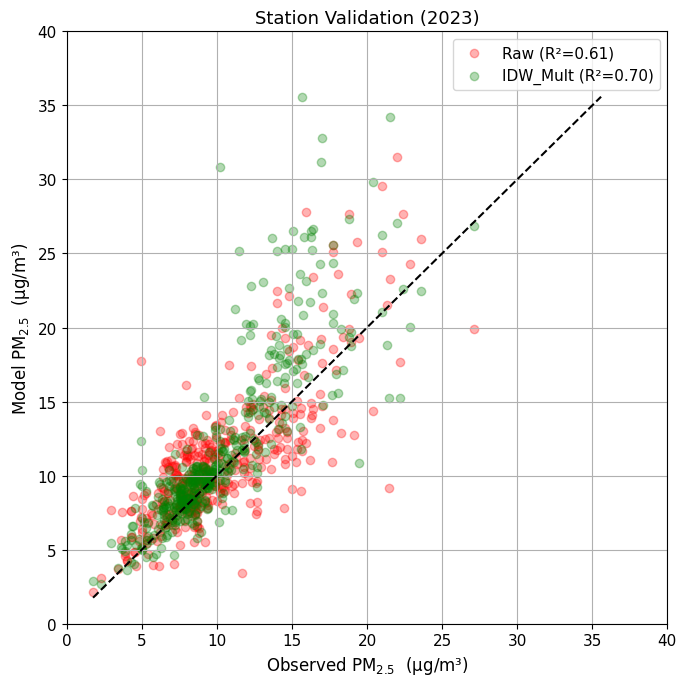

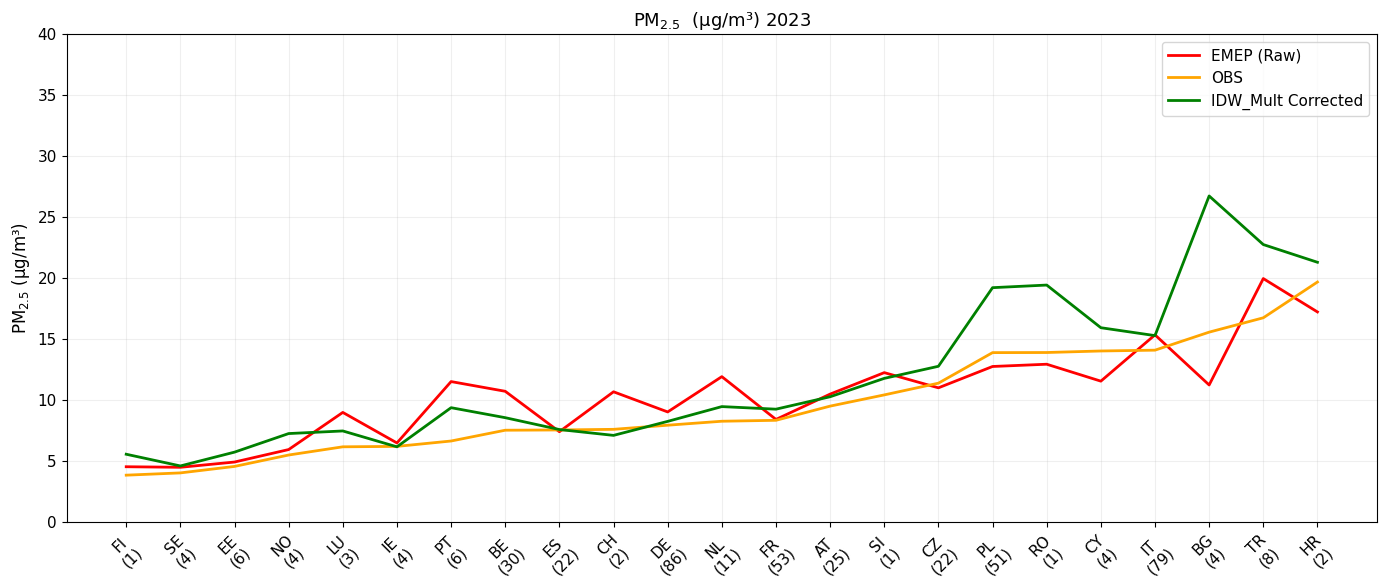

In [19]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2023.nc")
ds_wdi = xr.open_dataset("Scen_2023_NKUA_PM25_CSA.Cell.Mult.IDW_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_PM25_rh50"].values
wdi = ds_wdi["SURF_ug_PM25_rh50"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_PM25_2023.csv")

if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. BILINEAR INTERPOLATION
# ======================================================
def bilinear_interp(lon_pt, lat_pt, lon, lat, field):

    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon) - 2)
    j = np.clip(j, 0, len(lat) - 2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    Q11 = field[j, i]
    Q21 = field[j, i+1]
    Q12 = field[j+1, i]
    Q22 = field[j+1, i+1]

    return (
        Q11 * (x2 - lon_pt) * (y2 - lat_pt) +
        Q21 * (lon_pt - x1) * (y2 - lat_pt) +
        Q12 * (x2 - lon_pt) * (lat_pt - y1) +
        Q22 * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(bilinear_interp(lo, la, lon, lat, raw))
    wdi_vals.append(bilinear_interp(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

# compute once
r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nADI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"IDW_Mult (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')

plt.xlabel("Observed PM$_{2.5}$  (µg/m³)")
plt.ylabel("Model PM$_{2.5}$  (µg/m³)")
plt.title("Station Validation (2023)")
plt.xlim(0,40)
plt.ylim(0,40)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="IDW_Mult Corrected")

plt.xticks(x, labels, rotation=45)
plt.ylabel("PM$_{2.5}$ (µg/m³)")
plt.title("PM$_{2.5}$  (µg/m³) 2023")
plt.ylim(0,40)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 3.8510680947070632
MAE: 2.9033679138282866
Bias: 1.9934758279552327
R: 0.7663786253794099
R² (corr): 0.5873361974384339
R² (true): 0.12835636598149036

ADI
RMSE: 4.586032631979629
MAE: 3.1047655372044063
Bias: 2.8616546993785095
R: 0.8591964234463946
R² (corr): 0.7382184940630762
R² (true): -0.23609214931773503


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)



===== COUNTRY METRICS =====
   Country  RMSE_Raw   RMSE_WDI  Bias_Raw   Bias_WDI    R2_Raw    R2_WDI   N
3       CH  4.541475   0.480930  4.522708   0.477955  1.000000  1.000000   2
12      IE  1.056765   0.770392  0.642099   0.304726  0.421718  0.804341   4
20      SE  0.771162   0.993891  0.648879   0.769776  0.990979  0.936378   4
16      NO  2.833435   1.695154  0.480642   1.371115  0.219250  0.814431   4
6       DE  3.016868   1.750257  2.423615   1.534729  0.194634  0.744803  86
14      LU  3.067564   1.811496  2.931710   1.427443  0.642928  0.149008   3
15      NL  4.293688   1.814297  4.188090   1.558406  0.084139  0.071303  11
9       FI  0.777176   1.880036  0.777176   1.880036       NaN       NaN   1
0       AT  2.502465   2.162722  2.045428   1.859400  0.560165  0.793781  25
8       ES  2.270186   2.184395 -0.159330   0.093299  0.247175  0.250722  22
10      FR  1.954590   2.477861  1.094362   1.936195  0.342108  0.358371  53
1       BE  4.814858   2.603507  4.764495   2.4

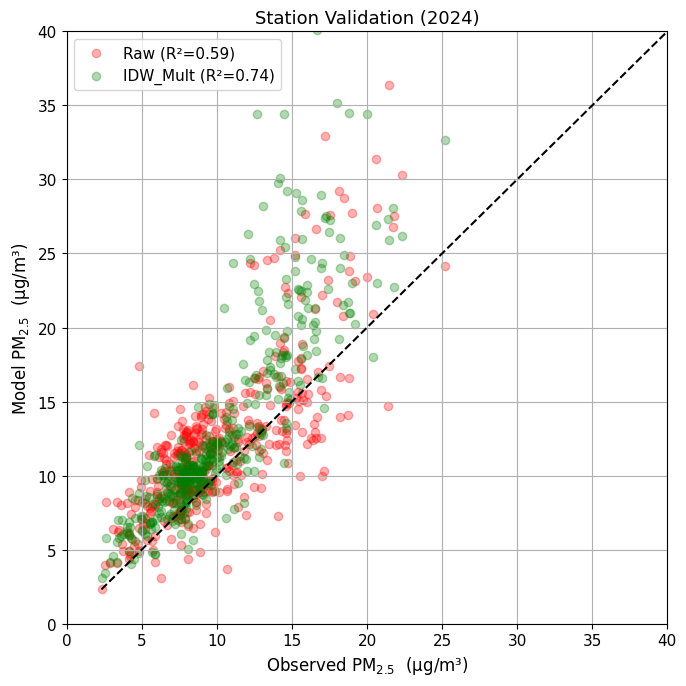

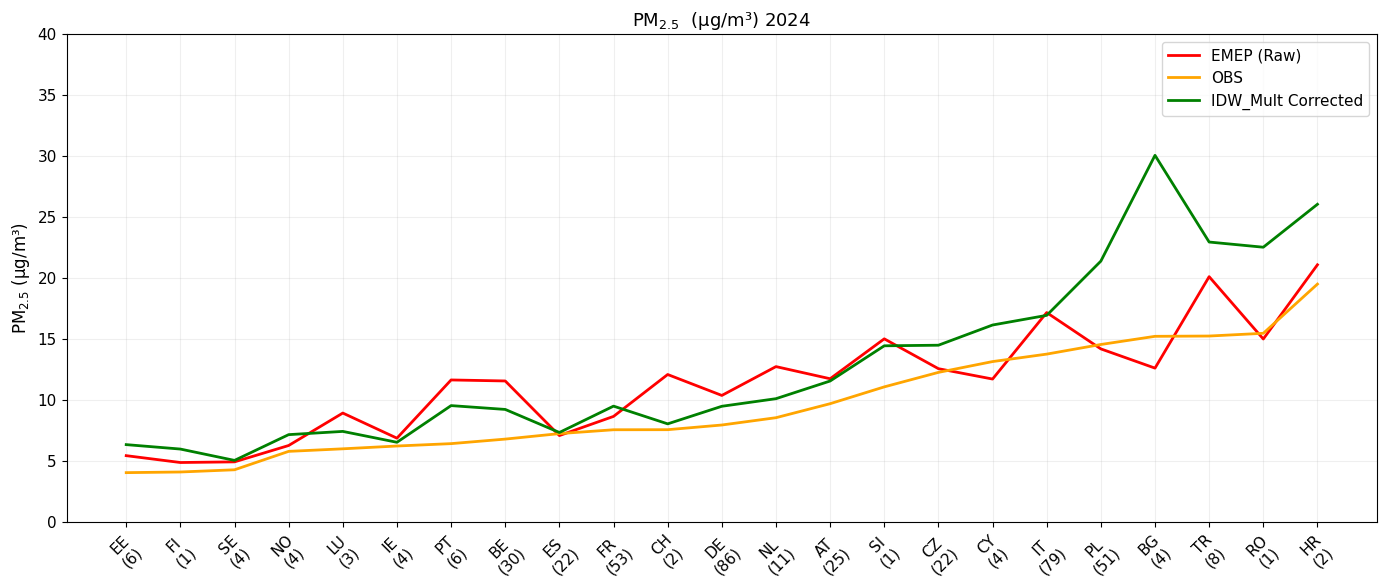

In [20]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2024.nc")
ds_wdi = xr.open_dataset("Scen_2024_NKUA_PM25_CSA.Cell.Mult.IDW_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_PM25_rh50"].values
wdi = ds_wdi["SURF_ug_PM25_rh50"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_PM25_2024.csv")

if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. BILINEAR INTERPOLATION
# ======================================================
def bilinear_interp(lon_pt, lat_pt, lon, lat, field):

    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon) - 2)
    j = np.clip(j, 0, len(lat) - 2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    Q11 = field[j, i]
    Q21 = field[j, i+1]
    Q12 = field[j+1, i]
    Q22 = field[j+1, i+1]

    return (
        Q11 * (x2 - lon_pt) * (y2 - lat_pt) +
        Q21 * (lon_pt - x1) * (y2 - lat_pt) +
        Q12 * (x2 - lon_pt) * (lat_pt - y1) +
        Q22 * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(bilinear_interp(lo, la, lon, lat, raw))
    wdi_vals.append(bilinear_interp(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

# compute once
r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nADI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"IDW_Mult (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')

plt.xlabel("Observed PM$_{2.5}$  (µg/m³)")
plt.ylabel("Model PM$_{2.5}$  (µg/m³)")
plt.title("Station Validation (2024)")
plt.xlim(0,40)
plt.ylim(0,40)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="IDW_Mult Corrected")

plt.xticks(x, labels, rotation=45)
plt.ylabel("PM$_{2.5}$ (µg/m³)")
plt.title("PM$_{2.5}$  (µg/m³) 2024")
plt.ylim(0,40)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [22]:
import numpy as np
import pandas as pd
import netCDF4 as nc
from sklearn.neighbors import BallTree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from tqdm import tqdm
import itertools

# ======================================================
# LOAD DATA
# ======================================================
df = pd.read_csv("basePM25_gridcell_average.csv")
df["bias_ratio"] = df["SURF_ug_PM25_rh50"] / df["nearest_SURF_ug_PM25_rh50"]

dataset = nc.Dataset("EMEP_yearly_2015.nc", "r")
lon = dataset.variables["lon"][:]
lat = dataset.variables["lat"][:]
model = dataset.variables["SURF_ug_PM25_rh50"][0, :, :]
dataset.close()

# ======================================================
# PREPARE DATA
# ======================================================
cell_points = np.column_stack([
    np.radians(df["nearest_grid_lat"].values),
    np.radians(df["nearest_grid_lon"].values)
])

bias_values = df["bias_ratio"].values
obs_values = df["SURF_ug_PM25_rh50"].values

# Precompute grid indices ONCE
cell_indices = [
    (
        np.argmin(np.abs(lat - df["nearest_grid_lat"].iloc[i])),
        np.argmin(np.abs(lon - df["nearest_grid_lon"].iloc[i]))
    )
    for i in range(len(df))
]

# ======================================================
# PARAMETERS
# ======================================================
p_values = np.arange(0.2, 3.1, 0.1)
k_values = np.arange(2, 41)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

# ======================================================
# GRID SEARCH
# ======================================================
with tqdm(total=len(p_values) * len(k_values), desc="Grid Search") as pbar:

    for p, k in itertools.product(p_values, k_values):

        all_val_obs = []
        all_val_pred = []

        for train_idx, val_idx in kf.split(cell_points):

            train_points = cell_points[train_idx]
            train_bias = bias_values[train_idx]

            val_points = cell_points[val_idx]
            val_obs = obs_values[val_idx]

            tree = BallTree(train_points, metric="haversine")
            dists, idxs = tree.query(val_points, k=k)

            dists = np.maximum(dists, 1e-12)

            weights = 1 / (dists ** p)
            weights /= weights.sum(axis=1, keepdims=True)

            interpolated_bias = np.sum(weights * train_bias[idxs], axis=1)

            val_pred = []

            for i_local, idx_global in enumerate(val_idx):
                i_grid, j_grid = cell_indices[idx_global]
                val_pred.append(model[i_grid, j_grid] * interpolated_bias[i_local])

            val_pred = np.array(val_pred)

            all_val_obs.extend(val_obs)
            all_val_pred.extend(val_pred)

        # --- METRICS ---
        all_val_obs = np.array(all_val_obs)
        all_val_pred = np.array(all_val_pred)

        rmse_val = np.sqrt(mean_squared_error(all_val_obs, all_val_pred))
        mae_val = mean_absolute_error(all_val_obs, all_val_pred)
        mbe_val = np.mean(all_val_pred - all_val_obs)
        r2_val = r2_score(all_val_obs, all_val_pred)

        results.append((p, k, rmse_val, mae_val, mbe_val, r2_val))

        pbar.update(1)

# ======================================================
# RESULTS TABLE
# ======================================================
results_df = pd.DataFrame(
    results,
    columns=["p", "k", "RMSE", "MAE", "MBE", "R2"]
)

results_df.to_csv("fast_gridsearch_metrics.csv", index=False)

# ======================================================
# SELECT BEST PER METRIC
# ======================================================
best_rmse_row = results_df.loc[results_df["RMSE"].idxmin()]
best_mae_row  = results_df.loc[results_df["MAE"].idxmin()]
best_mbe_row  = results_df.iloc[(results_df["MBE"].abs()).idxmin()]

print("\n===== BEST MODELS =====")

print("\nBEST RMSE")
print(best_rmse_row)

print("\nBEST MAE")
print(best_mae_row)

print("\nBEST MBE (closest to 0)")
print(best_mbe_row)

selected_models = {
    "RMSE": (best_rmse_row["p"], best_rmse_row["k"]),
    "MAE":  (best_mae_row["p"],  best_mae_row["k"]),
    "MBE":  (best_mbe_row["p"],  best_mbe_row["k"])
}

# ======================================================
# APPLY BEST MODELS
# ======================================================
print("\nApplying BEST models...")

lon_mesh, lat_mesh = np.meshgrid(lon, lat)
grid_points = np.column_stack([
    np.radians(lat_mesh.ravel()),
    np.radians(lon_mesh.ravel())
])

tree = BallTree(cell_points, metric="haversine")

for name, (p_sel, k_sel) in selected_models.items():

    print(f"\nModel optimized for {name}: p={p_sel}, k={k_sel}")

    dists, idxs = tree.query(grid_points, k=int(k_sel))
    dists = np.maximum(dists, 1e-12)

    weights = 1 / (dists ** p_sel)
    weights /= weights.sum(axis=1, keepdims=True)

    final_bias = np.sum(weights * bias_values[idxs], axis=1)
    final_bias = final_bias.reshape(model.shape)

    # ==============================
    # SAVE OUTPUT
    # ==============================
    out_name = f"BaseCase_PM25_IDW_{name}_p{p_sel:.2f}_k{k_sel}.nc"

    out_nc = nc.Dataset(out_name, "w", format="NETCDF4")

    out_nc.createDimension("lat", len(lat))
    out_nc.createDimension("lon", len(lon))

    lat_var = out_nc.createVariable("lat", "f4", ("lat",))
    lon_var = out_nc.createVariable("lon", "f4", ("lon",))
    bias_var = out_nc.createVariable("Interpolated_Bias", "f4", ("lat", "lon"))

    lat_var[:] = lat
    lon_var[:] = lon
    bias_var[:, :] = final_bias

    out_nc.close()

    print(f" Saved: {out_name}")

Grid Search: 100%|██████████| 1131/1131 [00:24<00:00, 45.45it/s]



===== BEST MODELS =====

BEST RMSE
p        1.500000
k       15.000000
RMSE     3.701120
MAE      2.308339
MBE      0.103137
R2       0.694904
Name: 520, dtype: float64

BEST MAE
p        1.300000
k       13.000000
RMSE     3.711664
MAE      2.295957
MBE      0.129442
R2       0.693164
Name: 440, dtype: float64

BEST MBE (closest to 0)
p       2.800000
k       4.000000
RMSE    4.015169
MAE     2.531363
MBE     0.000107
R2      0.640932
Name: 1016, dtype: float64

Applying BEST models...

Model optimized for RMSE: p=1.5000000000000004, k=15.0
 Saved: BaseCase_PM25_IDW_RMSE_p1.50_k15.0.nc

Model optimized for MAE: p=1.3000000000000003, k=13.0
 Saved: BaseCase_PM25_IDW_MAE_p1.30_k13.0.nc

Model optimized for MBE: p=2.800000000000001, k=4.0
 Saved: BaseCase_PM25_IDW_MBE_p2.80_k4.0.nc


In [26]:
import netCDF4 as nc
import numpy as np
import shutil

# ======================================================
# FILES
# ======================================================
original_nc_path = "EMEP_yearly_2015.nc"

bias_files = {
    "RMSE": "BaseCase_PM25_IDW_RMSE_p1.50_k15.0.nc",
    "MAE":  "BaseCase_PM25_IDW_MAE_p1.30_k13.0.nc",
    "MBE":  "BaseCase_PM25_IDW_MBE_p2.80_k4.0.nc"
}

# ======================================================
# LOOP OVER MODELS
# ======================================================
for name, bias_path in bias_files.items():

    print(f"\nProcessing BASECASE: {name}")

    corrected_tmp = f"BaseCase_Corrected_PM25_{name}.nc"
    final_output  = f"BaseCase_UoA_PM25_{name}_SCA.Cell.Mult.IDW_CORR_YEARLY.nc"

    with nc.Dataset(original_nc_path, "r") as original_nc, \
         nc.Dataset(bias_path, "r") as bias_nc:

        lon = original_nc.variables["lon"][:]
        lat = original_nc.variables["lat"][:]
        time = original_nc.variables["time"][:]
        pm25_original = original_nc.variables["SURF_ug_PM25_rh50"][:]

        bias = bias_nc.variables["Interpolated_Bias"][:]
        bias = np.maximum(bias, 0.1)

        pm25_corrected = pm25_original * bias

        # ===== TEMP FILE =====
        with nc.Dataset(corrected_tmp, "w", format="NETCDF4") as tmp:

            tmp.createDimension("time", None)
            tmp.createDimension("lat", len(lat))
            tmp.createDimension("lon", len(lon))

            tmp.createVariable("time", "f4", ("time",))[:] = time
            tmp.createVariable("lat", "f4", ("lat",))[:] = lat
            tmp.createVariable("lon", "f4", ("lon",))[:] = lon

            var = tmp.createVariable("PM25_corr", "f4", ("time","lat","lon"))
            var[:] = pm25_corrected

    # ===== FINAL JRC FORMAT =====
    shutil.copy(corrected_tmp, final_output)

    with nc.Dataset(corrected_tmp, "r") as src, \
         nc.Dataset(final_output, "w", format="NETCDF4") as dst:

        lon = src.variables["lon"][:]
        lat = src.variables["lat"][:]
        time = src.variables["time"][:]
        data = src.variables["PM25_corr"][:]

        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)

        dst.createVariable("lon", "f4", ("lon",))[:] = lon
        dst.createVariable("lat", "f4", ("lat",))[:] = lat
        dst.createVariable("time", "f4", ("time",))[:] = time

        var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon","lat","time"))
        var[:, :, :] = np.transpose(data, (2,1,0))

    print(f" Saved: {final_output}")


Processing BASECASE: RMSE
 Saved: BaseCase_UoA_PM25_RMSE_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

Processing BASECASE: MAE
 Saved: BaseCase_UoA_PM25_MAE_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

Processing BASECASE: MBE
 Saved: BaseCase_UoA_PM25_MBE_SCA.Cell.Mult.IDW_CORR_YEARLY.nc


In [27]:
# ======================================================
# SCENARIO FILE
# ======================================================
scenario_nc = "EMEP_yearly_2022.nc"

for name, bias_path in bias_files.items():

    print(f"\nProcessing SCENARIO: {name}")

    corrected_tmp = f"Scenario_Corrected_PM25_{name}.nc"
    final_output  = f"Scen_2022_UoA_PM25_{name}_SCA.Cell.Mult.IDW_CORR_YEARLY.nc"

    with nc.Dataset(scenario_nc, "r") as scen_nc, \
         nc.Dataset(bias_path, "r") as bias_nc:

        lon = scen_nc.variables["lon"][:]
        lat = scen_nc.variables["lat"][:]
        time = scen_nc.variables["time"][:]

        pm25 = scen_nc.variables["SURF_ug_PM25_rh50"][:]
        bias = bias_nc.variables["Interpolated_Bias"][:]

        bias = np.maximum(bias, 0.1)

        corrected = pm25 * bias

        # TEMP
        with nc.Dataset(corrected_tmp, "w", format="NETCDF4") as tmp:

            tmp.createDimension("time", None)
            tmp.createDimension("lat", len(lat))
            tmp.createDimension("lon", len(lon))

            tmp.createVariable("time", "f4", ("time",))[:] = time
            tmp.createVariable("lat", "f4", ("lat",))[:] = lat
            tmp.createVariable("lon", "f4", ("lon",))[:] = lon

            var = tmp.createVariable("PM25_corr", "f4", ("time","lat","lon"))
            var[:] = corrected

    # FINAL FORMAT
    shutil.copy(corrected_tmp, final_output)

    with nc.Dataset(corrected_tmp, "r") as src, \
         nc.Dataset(final_output, "w", format="NETCDF4") as dst:

        lon = src.variables["lon"][:]
        lat = src.variables["lat"][:]
        time = src.variables["time"][:]
        data = src.variables["PM25_corr"][:]

        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)

        dst.createVariable("lon", "f4", ("lon",))[:] = lon
        dst.createVariable("lat", "f4", ("lat",))[:] = lat
        dst.createVariable("time", "f4", ("time",))[:] = time

        var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon","lat","time"))
        var[:, :, :] = np.transpose(data, (2,1,0))

    print(f" Saved: {final_output}")


Processing SCENARIO: RMSE
 Saved: Scen_2022_UoA_PM25_RMSE_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

Processing SCENARIO: MAE
 Saved: Scen_2022_UoA_PM25_MAE_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

Processing SCENARIO: MBE
 Saved: Scen_2022_UoA_PM25_MBE_SCA.Cell.Mult.IDW_CORR_YEARLY.nc


In [28]:
import numpy as np
import os

input_dir = "/content/PM25"
output_dir = "/content/Results_PM25"

variables_to_fix = [
    "SURF_ug_NO2",
    "SURF_ug_O3",              # corrected name
    "SURF_ug_PM25_rh50"
]

correct_dims = ("time", "lat", "lon")

os.makedirs(output_dir, exist_ok=True)

for file in os.listdir(input_dir):
    if file.endswith(".nc"):

        input_path = os.path.join(input_dir, file)
        output_path = os.path.join(output_dir, file)

        print(f"\nProcessing: {file}")

        with nc.Dataset(input_path, "r") as src:
            lon = src.variables["lon"][:]
            lat = src.variables["lat"][:]
            time = src.variables["time"][:]

            global_attrs = {attr: src.getncattr(attr) for attr in src.ncattrs()}

            with nc.Dataset(output_path, "w", format="NETCDF4") as dst:

                # === FIXED DIMENSIONS ===
                dst.createDimension("lon", len(lon))
                dst.createDimension("lat", len(lat))
                dst.createDimension("time", len(time))   # NOT unlimited

                # === COORDINATES (correct dtype) ===
                lon_var = dst.createVariable("lon", "f8", ("lon",))
                lat_var = dst.createVariable("lat", "f8", ("lat",))
                time_var = dst.createVariable("time", "f8", ("time",))

                lon_var[:] = lon
                lat_var[:] = lat
                time_var[:] = time

                # Copy coordinate attributes
                for coord in ["lon", "lat", "time"]:
                    for attr in src.variables[coord].ncattrs():
                        getattr(dst.variables[coord], "setncattr")(
                            attr, src.variables[coord].getncattr(attr)
                        )

                # === Global attributes ===
                for attr, value in global_attrs.items():
                    dst.setncattr(attr, value)

                # === Variables ===
                for var_name in variables_to_fix:

                    if var_name not in src.variables:
                        print(f"  ⚠ {var_name} not found.")
                        continue

                    var = src.variables[var_name]
                    dims = var.dimensions
                    data = var[:]
                    var_attrs = {a: var.getncattr(a) for a in var.ncattrs()}

                    # === Reshape if needed ===
                    if dims != correct_dims:

                        print(f"   Reshaping {var_name}: {dims} → {correct_dims}")

                        if dims == ("lon", "lat", "time"):
                            data = np.transpose(data, (2, 1, 0))
                        elif dims == ("lat", "lon", "time"):
                            data = np.transpose(data, (2, 0, 1))
                        else:
                            print(f"   ⚠ Unknown dimension order {dims}")
                            continue

                    # === Write variable ===
                    fill_value = var_attrs.pop("_FillValue", -9999.0)

                    var_out = dst.createVariable(
                        var_name,
                        "f4",
                        correct_dims,
                        fill_value=fill_value
                    )

                    for attr, value in var_attrs.items():
                        var_out.setncattr(attr, value)

                    var_out[:] = data

        print(f"  ✔ Saved to {output_path}")

print("\n✔ All files processed correctly.")


Processing: BaseCase_UoA_PM25_MAE_SCA.Cell.Mult.IDW_CORR_YEARLY.nc
  ⚠ SURF_ug_NO2 not found.
  ⚠ SURF_ug_O3 not found.
   Reshaping SURF_ug_PM25_rh50: ('lon', 'lat', 'time') → ('time', 'lat', 'lon')
  ✔ Saved to /content/Results_PM25/BaseCase_UoA_PM25_MAE_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

Processing: Scen_2022_UoA_PM25_RMSE_SCA.Cell.Mult.IDW_CORR_YEARLY.nc
  ⚠ SURF_ug_NO2 not found.
  ⚠ SURF_ug_O3 not found.
   Reshaping SURF_ug_PM25_rh50: ('lon', 'lat', 'time') → ('time', 'lat', 'lon')
  ✔ Saved to /content/Results_PM25/Scen_2022_UoA_PM25_RMSE_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

Processing: Scen_2022_UoA_PM25_MAE_SCA.Cell.Mult.IDW_CORR_YEARLY.nc
  ⚠ SURF_ug_NO2 not found.
  ⚠ SURF_ug_O3 not found.
   Reshaping SURF_ug_PM25_rh50: ('lon', 'lat', 'time') → ('time', 'lat', 'lon')
  ✔ Saved to /content/Results_PM25/Scen_2022_UoA_PM25_MAE_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

Processing: BaseCase_UoA_PM25_RMSE_SCA.Cell.Mult.IDW_CORR_YEARLY.nc
  ⚠ SURF_ug_NO2 not found.
  ⚠ SURF_ug_O3 not found.


--- Model_Raw ---
RMSE: 5.259
MAE: 3.441
Bias: -1.061
R2: 0.445

--- Model_WDI ---
RMSE: 0.942
MAE: 0.525
Bias: -0.134
R2: 0.981

--- Model_WDI2 ---
RMSE: 0.967
MAE: 0.550
Bias: -0.132
R2: 0.980

--- Model_WDI3 ---
RMSE: 0.897
MAE: 0.464
Bias: -0.154
R2: 0.983

--- Model_WDI4 ---
RMSE: 0.901
MAE: 0.475
Bias: -0.144
R2: 0.982


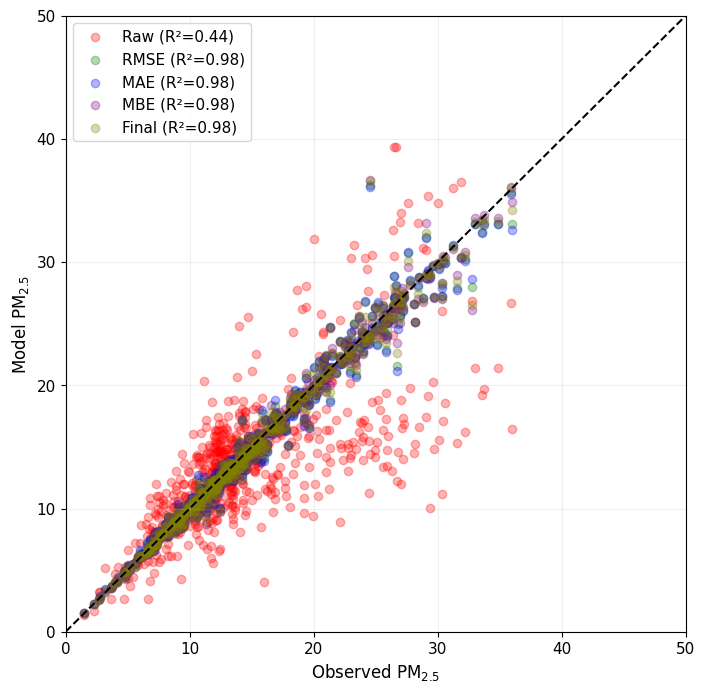

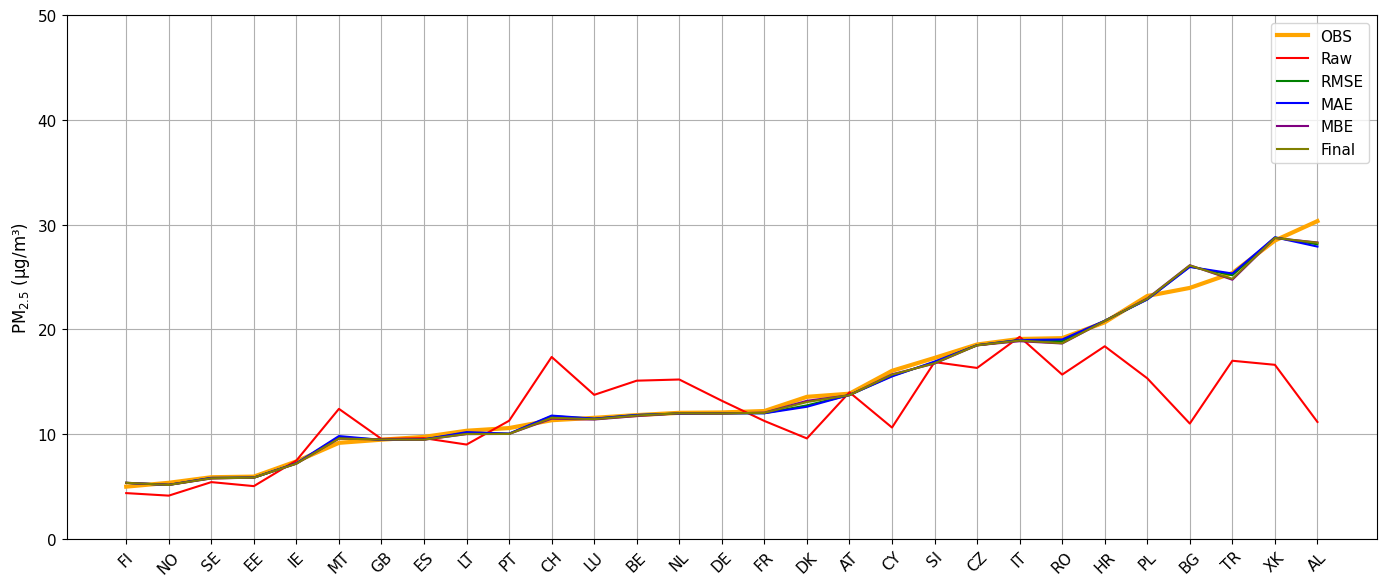

In [33]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2015.nc")
ds_wdi = xr.open_dataset("BaseCase_UoA_PM25_RMSE_SCA.Cell.Mult.IDW_CORR_YEARLY.nc")
ds_wdi2 = xr.open_dataset("BaseCase_UoA_PM25_MAE_SCA.Cell.Mult.IDW_CORR_YEARLY.nc")
ds_wdi3 = xr.open_dataset("BaseCase_UoA_PM25_MBE_SCA.Cell.Mult.IDW_CORR_YEARLY.nc")
ds_wdi4 = xr.open_dataset("BaseCase_NKUA_PM25_CSA.Cell.Mult.IDW_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_PM25_rh50"].values
wdi = ds_wdi["SURF_ug_PM25_rh50"].values
wdi2 = ds_wdi2["SURF_ug_PM25_rh50"].values
wdi3 = ds_wdi3["SURF_ug_PM25_rh50"].values
wdi4 = ds_wdi4["SURF_ug_PM25_rh50"].values

# Handle time dimension
def handle_dim(arr):
    return arr[0] if arr.ndim == 3 else arr

raw = handle_dim(raw)
wdi = handle_dim(wdi)
wdi2 = handle_dim(wdi2)
wdi3 = handle_dim(wdi3)
wdi4 = handle_dim(wdi4)

ds_raw.close()
ds_wdi.close()
ds_wdi2.close()
ds_wdi3.close()
ds_wdi4.close()

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_PM25_2015.csv")

if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. BILINEAR INTERPOLATION
# ======================================================
def bilinear_interp(lon_pt, lat_pt, lon, lat, field):
    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon) - 2)
    j = np.clip(j, 0, len(lat) - 2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    return (
        field[j, i] * (x2 - lon_pt) * (y2 - lat_pt) +
        field[j, i+1] * (lon_pt - x1) * (y2 - lat_pt) +
        field[j+1, i] * (x2 - lon_pt) * (lat_pt - y1) +
        field[j+1, i+1] * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_v, wdi_v, wdi2_v, wdi3_v, wdi4_v = [], [], [], [], []

for _, row in df.iterrows():
    lo, la = row["Longitude"], row["Latitude"]

    raw_v.append(bilinear_interp(lo, la, lon, lat, raw))
    wdi_v.append(bilinear_interp(lo, la, lon, lat, wdi))
    wdi2_v.append(bilinear_interp(lo, la, lon, lat, wdi2))
    wdi3_v.append(bilinear_interp(lo, la, lon, lat, wdi3))
    wdi4_v.append(bilinear_interp(lo, la, lon, lat, wdi4))

df["Model_Raw"] = raw_v
df["Model_WDI"] = wdi_v
df["Model_WDI2"] = wdi2_v
df["Model_WDI3"] = wdi3_v
df["Model_WDI4"] = wdi4_v

# ======================================================
# 5. CLEAN & METRICS
# ======================================================
df = df.dropna(subset=[
    "Average", "Model_Raw", "Model_WDI",
    "Model_WDI2", "Model_WDI3", "Model_WDI4"
])

def get_stats(model, obs):
    r = np.corrcoef(model, obs)[0,1]
    return {
        "RMSE": np.sqrt(np.mean((model - obs)**2)),
        "MAE": np.mean(np.abs(model - obs)),
        "Bias": np.mean(model - obs),
        "R2": r**2
    }

# Print stats
obs = df["Average"].values

for m_name in ["Model_Raw", "Model_WDI", "Model_WDI2", "Model_WDI3", "Model_WDI4"]:
    stats = get_stats(df[m_name].values, obs)
    print(f"\n--- {m_name} ---")
    for k, v in stats.items():
        print(f"{k}: {v:.3f}")

# ======================================================
# 6. SCATTER
# ======================================================
plt.figure(figsize=(8,8))

models = [
    ("Model_Raw", "red", "Raw"),
    ("Model_WDI", "green", "RMSE"),
    ("Model_WDI2", "blue", "MAE"),
    ("Model_WDI3", "purple", "MBE"),
    ("Model_WDI4", "olive", "Final")
]

for col, colr, lbl in models:
    r2 = get_stats(df[col], obs)["R2"]
    plt.scatter(obs, df[col], label=f"{lbl} (R²={r2:.2f})", alpha=0.3, color=colr)

# FIXED 1:1 line
plt.plot([0, 50], [0, 50], 'k--')

plt.xlabel("Observed PM$_{2.5}$")
plt.ylabel("Model PM$_{2.5}$")
plt.xlim(0,50)
plt.ylim(0,50)
plt.grid(alpha=0.2)
plt.legend()
plt.show()

# ======================================================
# 7. COUNTRY PLOT (FIXED)
# ======================================================
country_mean = df.groupby("Country")[[
    "Average", "Model_Raw", "Model_WDI",
    "Model_WDI2", "Model_WDI3", "Model_WDI4"
]].mean().sort_values("Average")

x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["Average"],  color='orange', linewidth=3, label="OBS")
plt.plot(x, country_mean["Model_Raw"], color='red', label="Raw")
plt.plot(x, country_mean["Model_WDI"], color='green', label="RMSE")
plt.plot(x, country_mean["Model_WDI2"], color='blue', label="MAE")
plt.plot(x, country_mean["Model_WDI3"], color='purple', label="MBE")
plt.plot(x, country_mean["Model_WDI4"], color='olive', label="Final")

plt.xticks(x, country_mean.index, rotation=45)
plt.ylabel("PM$_{2.5}$ (µg/m³)")
plt.ylim(0,50)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


--- Model_Raw ---
RMSE: 5.259
MAE: 3.441
Bias: -1.061
R2: 0.445

--- Model_WDI ---
RMSE: 2.571
MAE: 2.008
Bias: -1.301
R2: 0.895

--- Model_WDI2 ---
RMSE: 2.574
MAE: 2.012
Bias: -1.301
R2: 0.894

--- Model_WDI3 ---
RMSE: 2.613
MAE: 2.033
Bias: -1.313
R2: 0.892

--- Model_WDI4 ---
RMSE: 2.585
MAE: 2.013
Bias: -1.307
R2: 0.894


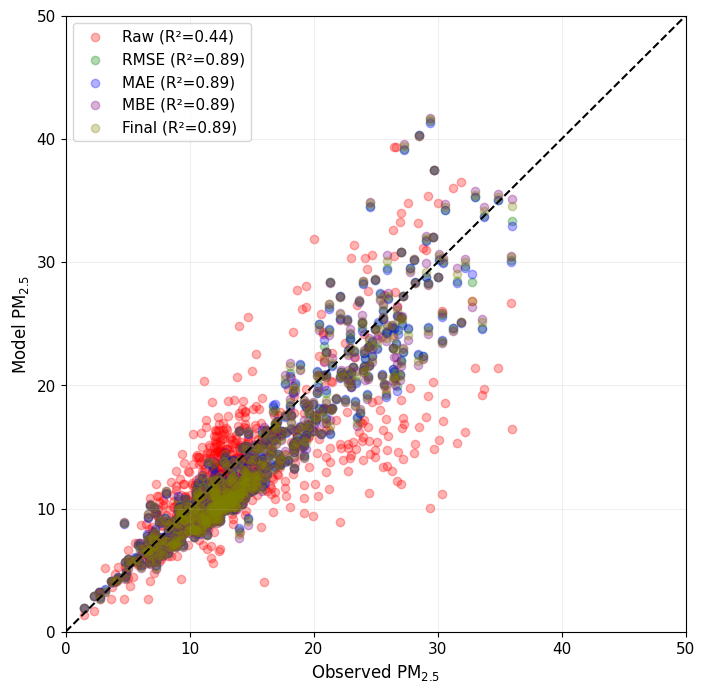

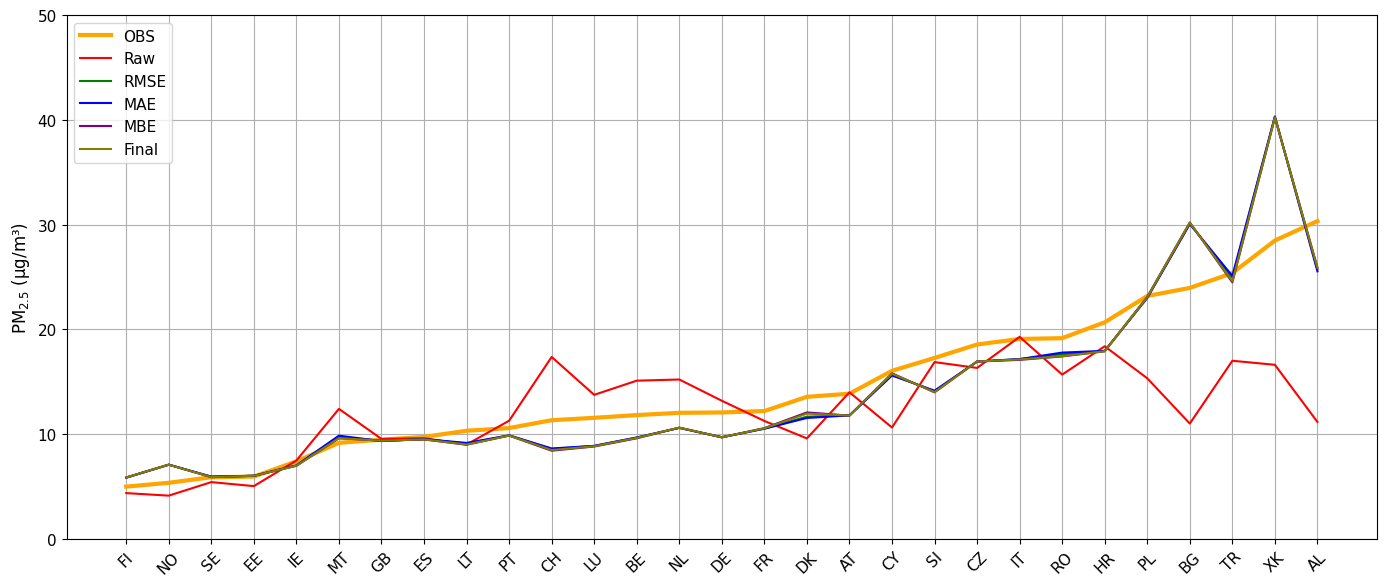

In [34]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2015.nc")
ds_wdi = xr.open_dataset("Scen_2022_UoA_PM25_RMSE_SCA.Cell.Mult.IDW_CORR_YEARLY.nc")
ds_wdi2 = xr.open_dataset("Scen_2022_UoA_PM25_MAE_SCA.Cell.Mult.IDW_CORR_YEARLY.nc")
ds_wdi3 = xr.open_dataset("Scen_2022_UoA_PM25_MBE_SCA.Cell.Mult.IDW_CORR_YEARLY.nc")
ds_wdi4 = xr.open_dataset("Scen_2022_NKUA_PM25_CSA.Cell.Mult.IDW_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_PM25_rh50"].values
wdi = ds_wdi["SURF_ug_PM25_rh50"].values
wdi2 = ds_wdi2["SURF_ug_PM25_rh50"].values
wdi3 = ds_wdi3["SURF_ug_PM25_rh50"].values
wdi4 = ds_wdi4["SURF_ug_PM25_rh50"].values

# Handle time dimension
def handle_dim(arr):
    return arr[0] if arr.ndim == 3 else arr

raw = handle_dim(raw)
wdi = handle_dim(wdi)
wdi2 = handle_dim(wdi2)
wdi3 = handle_dim(wdi3)
wdi4 = handle_dim(wdi4)

ds_raw.close()
ds_wdi.close()
ds_wdi2.close()
ds_wdi3.close()
ds_wdi4.close()

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_PM25_2015.csv")

if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. BILINEAR INTERPOLATION
# ======================================================
def bilinear_interp(lon_pt, lat_pt, lon, lat, field):
    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon) - 2)
    j = np.clip(j, 0, len(lat) - 2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    return (
        field[j, i] * (x2 - lon_pt) * (y2 - lat_pt) +
        field[j, i+1] * (lon_pt - x1) * (y2 - lat_pt) +
        field[j+1, i] * (x2 - lon_pt) * (lat_pt - y1) +
        field[j+1, i+1] * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_v, wdi_v, wdi2_v, wdi3_v, wdi4_v = [], [], [], [], []

for _, row in df.iterrows():
    lo, la = row["Longitude"], row["Latitude"]

    raw_v.append(bilinear_interp(lo, la, lon, lat, raw))
    wdi_v.append(bilinear_interp(lo, la, lon, lat, wdi))
    wdi2_v.append(bilinear_interp(lo, la, lon, lat, wdi2))
    wdi3_v.append(bilinear_interp(lo, la, lon, lat, wdi3))
    wdi4_v.append(bilinear_interp(lo, la, lon, lat, wdi4))

df["Model_Raw"] = raw_v
df["Model_WDI"] = wdi_v
df["Model_WDI2"] = wdi2_v
df["Model_WDI3"] = wdi3_v
df["Model_WDI4"] = wdi4_v

# ======================================================
# 5. CLEAN & METRICS
# ======================================================
df = df.dropna(subset=[
    "Average", "Model_Raw", "Model_WDI",
    "Model_WDI2", "Model_WDI3", "Model_WDI4"
])

def get_stats(model, obs):
    r = np.corrcoef(model, obs)[0,1]
    return {
        "RMSE": np.sqrt(np.mean((model - obs)**2)),
        "MAE": np.mean(np.abs(model - obs)),
        "Bias": np.mean(model - obs),
        "R2": r**2
    }

# Print stats
obs = df["Average"].values

for m_name in ["Model_Raw", "Model_WDI", "Model_WDI2", "Model_WDI3", "Model_WDI4"]:
    stats = get_stats(df[m_name].values, obs)
    print(f"\n--- {m_name} ---")
    for k, v in stats.items():
        print(f"{k}: {v:.3f}")

# ======================================================
# 6. SCATTER
# ======================================================
plt.figure(figsize=(8,8))

models = [
    ("Model_Raw", "red", "Raw"),
    ("Model_WDI", "green", "RMSE"),
    ("Model_WDI2", "blue", "MAE"),
    ("Model_WDI3", "purple", "MBE"),
    ("Model_WDI4", "olive", "Final")
]

for col, colr, lbl in models:
    r2 = get_stats(df[col], obs)["R2"]
    plt.scatter(obs, df[col], label=f"{lbl} (R²={r2:.2f})", alpha=0.3, color=colr)

# FIXED 1:1 line
plt.plot([0, 50], [0, 50], 'k--')

plt.xlabel("Observed PM$_{2.5}$")
plt.ylabel("Model PM$_{2.5}$")
plt.xlim(0,50)
plt.ylim(0,50)
plt.grid(alpha=0.2)
plt.legend()
plt.show()

# ======================================================
# 7. COUNTRY PLOT (FIXED)
# ======================================================
country_mean = df.groupby("Country")[[
    "Average", "Model_Raw", "Model_WDI",
    "Model_WDI2", "Model_WDI3", "Model_WDI4"
]].mean().sort_values("Average")

x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["Average"],  color='orange', linewidth=3, label="OBS")
plt.plot(x, country_mean["Model_Raw"], color='red', label="Raw")
plt.plot(x, country_mean["Model_WDI"], color='green', label="RMSE")
plt.plot(x, country_mean["Model_WDI2"], color='blue', label="MAE")
plt.plot(x, country_mean["Model_WDI3"], color='purple', label="MBE")
plt.plot(x, country_mean["Model_WDI4"], color='olive', label="Final")

plt.xticks(x, country_mean.index, rotation=45)
plt.ylabel("PM$_{2.5}$ (µg/m³)")
plt.ylim(0,50)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()